# 3.4 — Attention et Transformer from scratch : jusqu'au mini-GPT

## Introduction

Les notebooks 3.1 à 3.3 ont construit le MLP pas à pas : sa rétropropagation, ses optimisateurs,
sa régularisation. Le modèle qui domine le traitement du langage depuis 2017 n'est **pas** un
MLP : c'est le **transformer** (Vaswani et al., *Attention Is All You Need*), et sa brique
centrale — l'**attention** — répond à une question que le MLP ne se pose même pas : *comment
laisser chaque élément d'une séquence choisir, tout seul, les autres éléments qui l'éclairent ?*

Ce notebook monte l'échelle entière, barreau par barreau, chacun exécuté :

1. le **problème séquentiel** : l'ordre est une information que le pooling moyen détruit ;
2. les **encodages positionnels sinusoïdaux** — une signature unique par position ;
3. l'**attention mono-tête à la main** : produits scalaires, softmax, matrice d'attention
   lisible sur une tâche interprétable (l'inversion d'une séquence), puis le **masque causal** ;
4. le **multi-têtes**, suivi de la preuve d'équivalence numérique avec
   `torch.nn.MultiheadAttention` à poids égaux ;
5. le **bloc transformer complet** : pré-normes, connexions résiduelles, MLP ;
6. un **mini-GPT de 1,25 million de paramètres** écrit dans ce notebook et **entraîné ici**,
   sur CPU, sur un texte français du domaine public (*Le Horla*, Maupassant, 1887) — courbe de
   perte et échantillons générés à deux températures dans les sorties ;
7. le **pont** vers les modèles 7B+ auto-hébergés de la série GenAI/Texte.

### Objectifs d'apprentissage

- écrire `attention(Q, K, V)` sans module de haut niveau et **lire** sa matrice de poids ;
- relier le masque causal à la tâche de prédiction du caractère suivant ;
- prouver qu'une implémentation maison est *numériquement identique* au module officiel ;
- entraîner un modèle génératif caractère par caractère, puis interpréter sa perte, son écart
  train/validation et ses échantillons.

### Prérequis

[3.1 — Rétropropagation](3.1-Retropropagation.ipynb) (chain rule, autograd),
[3.2 — Optimisateurs](3.2-Optimisateurs.ipynb) (Adam, schedules), 3.3 — Régularisation
(en cours d'intégration) ; aisance avec NumPy.

In [1]:
# Socle : torch sur CPU, numpy pour les manipulations exactes, matplotlib pour les matrices.
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
print("torch", torch.__version__, "| numpy", np.__version__, "| execution 100% CPU (< 4 min)")

torch 2.13.0+cpu | numpy 2.4.6 | execution 100% CPU (< 4 min)


## 1. Le problème séquentiel : l'ordre n'est pas une option

Commençons par le geste le plus simple pour représenter une phrase : additionner (ou moyenner)
les vecteurs de ses mots — le **sac de mots**. C'est exactement ce que fait un MLP auquel on
donnerait une phrase mise en commun : l'information d'ordre disparaît dans l'addition. Deux
phrases de vocabulaire identique et de sens opposé deviennent **indiscernables**.

In [2]:
# Deux phrases de vocabulaire identique, de sens oppose :
vocab = ["le", "la", "chat", "souris", "mange"]
onehot = {w: np.eye(len(vocab))[i] for i, w in enumerate(vocab)}

def sac_de_mots(phrase):
    return np.mean([onehot[w] for w in phrase.split()], axis=0)

vA = sac_de_mots("le chat mange la souris")
vB = sac_de_mots("la souris mange le chat")
print("sac de mots A (le chat mange la souris) :", np.round(vA, 3))
print("sac de mots B (la souris mange le chat) :", np.round(vB, 3))
print("vecteurs identiques ?", np.allclose(vA, vB))

sac de mots A (le chat mange la souris) : [0.2 0.2 0.2 0.2 0.2]
sac de mots B (la souris mange le chat) : [0.2 0.2 0.2 0.2 0.2]
vecteurs identiques ? True


### Lecture du résultat

Les deux vecteurs sont identiques au flottant près : le pooling moyen a fondu les mots dans un
ordre qui ne se retrouve plus nulle part. Or *qui mange qui* est précisément une question de
position. Il manque deux choses, et elles structureront tout le notebook :

1. **injecter la position** dans chaque vecteur — c'est le rôle de l'encodage positionnel
   (section 2) ;
2. **laisser les positions communiquer entre elles**, au lieu de les moyenner d'entrée de jeu —
   c'est le rôle de l'attention (section 3).

## 2. Les encodages positionnels sinusoïdaux

L'idée de Vaswani et al. : ajouter au vecteur de chaque *token* un vecteur qui ne dépend **que
de sa position** $t$, construit par une famille de sinus et cosinus de fréquences géométriques :

$$PE_{(t, 2i)} = \sin\!\big(t / 10000^{2i/d}\big), \qquad PE_{(t, 2i+1)} = \cos\!\big(t / 10000^{2i/d}\big)$$

Les basses dimensions oscillent lentement (elles encodent la position grossière), les hautes
dimensions vite (la position fine). Chaque ligne de la matrice ci-dessous est la signature d'une
position : deux positions quelconques ont des signatures différentes et séparables.

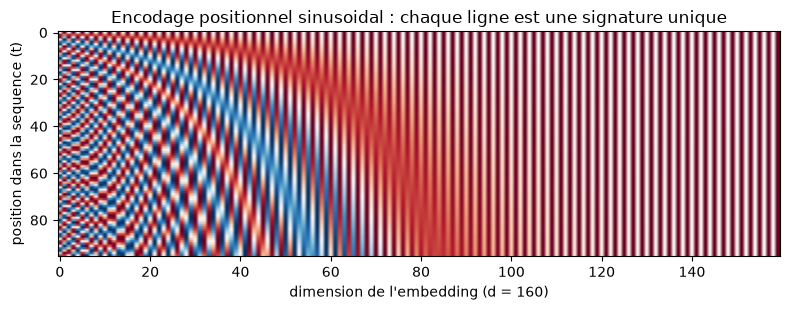

PE[0, :6]   = [0. 1. 0. 1. 0. 1.]
PE[50, :6]  = [-0.262  0.965  0.548  0.836  0.902 -0.432]
PE[95, :6]  = [ 0.683  0.73   0.154 -0.988  0.063  0.998]


In [3]:
def encodage_positionnel(T, d):
    """Signatures positionnelles de Vaswani et al. (2017), equation (1)."""
    pe = np.zeros((T, d))
    pos = np.arange(T)[:, None]
    div = np.exp(np.arange(0, d, 2) * (-math.log(10000.0) / d))
    pe[:, 0::2] = np.sin(pos * div)
    pe[:, 1::2] = np.cos(pos * div)
    return pe

pe = encodage_positionnel(96, 160)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.imshow(pe, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("dimension de l'embedding (d = 160)")
ax.set_ylabel("position dans la sequence (t)")
ax.set_title("Encodage positionnel sinusoidal : chaque ligne est une signature unique")
plt.tight_layout(); plt.show()
print("PE[0, :6]   =", np.round(pe[0, :6], 3))
print("PE[50, :6]  =", np.round(pe[50, :6], 3))
print("PE[95, :6]  =", np.round(pe[95, :6], 3))

### Lecture du résultat

À gauche (basses dimensions), les oscillations sont lentes : la position 0 et la position 50 y
sont encore proches — c'est une information de position *grossière*. À droite (hautes
dimensions), les oscillations sont rapides et distinguent les positions voisines. Le produit
scalaire $PE_{t} \cdot PE_{t'}$ décroît avec $|t - t'|$ : la similarité entre deux signatures
reflète leur **écart relatif**, propriété que l'attention exploitera. Ce vecteur s'ajoute à
l'embedding du token : le bloc suivant peut ainsi traiter *ce que c'est* et *où c'est*.

## 3. L'attention mono-tête, à la main

La formule du papier tient en une ligne :

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d}}\right) V$$

- la **requête** $Q$ demande : « qu'est-ce qui m'éclairerait, moi, position $i$ ? » ;
- chaque **clé** $K_j$ répond : « voici ce que je propose » ;
- le produit scalaire $Q_i \cdot K_j$ mesure l'accord entre la demande et l'offre ;
- le **softmax** par ligne transforme les scores en distribution : chaque position répartit
  **1,0 d'attention** entre les positions qu'elle lit ;
- la **valeur** $V_j$ est ce qui est effectivement rapporté, pondéré par ces coefficients.

Pour que la mécanique soit **lisible**, on la fait tourner sur une tâche où l'on peut construire
$Q$, $K$, $V$ à la main : **inverser une séquence**. La position $i$ doit rapporter le jeton
situé en $T{-}1{-}i$ — si l'attention réussit, sa matrice doit être **l'anti-diagonale**.

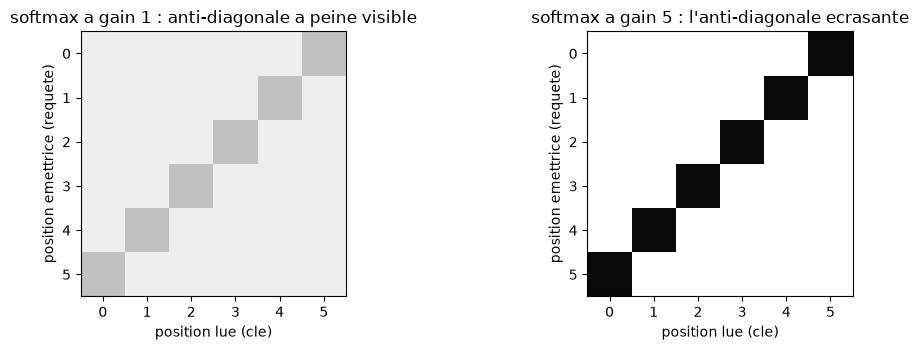

sequence entree : ['chat', 'oiseau', 'poisson', 'chien', 'renard', 'loup']
sequence recuperee par attention : ['loup', 'renard', 'chien', 'poisson', 'oiseau', 'chat']
poids de la requete 0 a gain 5 : [0.007 0.007 0.007 0.007 0.007 0.967] (somme 1.0 )


In [4]:
# Tache interpretable : INVERSER une sequence de jetons par attention pure.
jetons = ["chat", "oiseau", "poisson", "chien", "renard", "loup"]
T = len(jetons)

K = np.eye(T)          # chaque cles expose son identite de position (one-hot)
V = np.eye(T)          # chaque valeur expose le jeton qu'elle porte (one-hot : 6 jetons)
Q = np.eye(T)[::-1]    # la requete i cherche la position (T-1-i) : lignes renversees

def softmax_lignes(m):
    e = np.exp(m - m.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

brut = Q @ K.T               # 1 sur l'anti-diagonale, 0 ailleurs (ecarts TROP petits)
A_plat = softmax_lignes(brut)          # gain 1 : la geometrie noyee dans le softmax
A = softmax_lignes(brut * 5)           # gain 5 : l'anti-diagonale devient ecrasante
sortie = A @ V
inversion = [jetons[int(np.argmax(sortie[i]))] for i in range(T)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].imshow(A_plat, cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("softmax a gain 1 : anti-diagonale a peine visible")
axes[1].imshow(A, cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("softmax a gain 5 : l'anti-diagonale ecrasante")
for ax in axes:
    ax.set_xlabel("position lue (cle)")
    ax.set_ylabel("position emettrice (requete)")
plt.tight_layout(); plt.show()

print("sequence entree :", jetons)
print("sequence recuperee par attention :", inversion)
print("poids de la requete 0 a gain 5 :", np.round(A[0], 3), "(somme", round(A[0].sum(), 6), ")")

### Lecture du résultat — la netteté du softmax est un réglage, pas un hasard

À **gain 1**, l'anti-diagonale existe mais surnage à peine : nos scores bruts valent 1 contre
0, et un softmax à petit écart reste presque uniforme (≈ 0,19 partout). À **gain 5**, le même
pattern devient écrasant : la requête 0 met ~97 % de son budget d'attention sur la clé 5, la
requête 1 sur la clé 4 — et la sortie rapporte la séquence inversée. Trois points à retenir :

1. **chaque ligne de $A$ est une distribution** (somme exactement 1) : la position émettrice
   choisit *où lire*, jamais *combien au total* ;
2. la mise à l'échelle de la formule officielle — $1/\sqrt{d}$ — joue ce rôle **dans l'autre
   sens** : en dimension réelle, les produits scalaires de projections aléatoires ont un
   écart-type en $\sqrt{d}$ ; sans division, le softmax saturerait sur un seul point et le
   gradient disparaîtrait. Notre gain 5 compense un jouet à trop petits scores ; le
   $1/\sqrt{d}$ du papier empêche un modèle réel à trop gros scores. Même problème, directions
   opposées ;
3. dans un vrai modèle, $Q$, $K$, $V$ ne sont pas posés à la main — ce sont des **projections
   apprises** de l'embedding ($xW_q$, $xW_k$, $xW_v$). La matrice est lisible ici précisément
   parce que nous les avons construites.

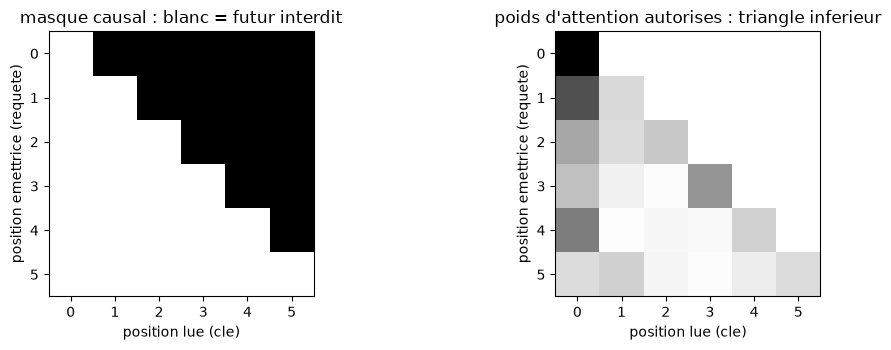

ligne 4 : poids sur les positions 0..4 = [0.589 0.014 0.064 0.051 0.282 0.   ]
poids du futur (positions 5..5) : [0.]


In [5]:
# Le masque causal : pour PREDIRE le caractere suivant, la position i ne doit lire
# que les positions <= i. On interdit explicitement le futur avant le softmax.
scores_toy = np.random.RandomState(0).randn(T, T)
masque = np.triu(np.ones((T, T), dtype=bool), k=1)          # True = futur interdit
scores_masques = np.where(masque, -1e9, scores_toy)          # -1e9 : softmax ~ 0

A_causale = np.exp(scores_masques - scores_masques.max(axis=-1, keepdims=True))
A_causale = A_causale / A_causale.sum(axis=-1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].imshow(masque.astype(int), cmap="binary")
axes[0].set_title("masque causal : blanc = futur interdit")
axes[1].imshow(A_causale, cmap="Greys", vmin=0)
axes[1].set_title("poids d'attention autorises : triangle inferieur")
for ax in axes:
    ax.set_xlabel("position lue (cle)")
    ax.set_ylabel("position emettrice (requete)")
plt.tight_layout(); plt.show()
print("ligne 4 : poids sur les positions 0..4 =", np.round(A_causale[4], 3))
print("poids du futur (positions 5..5) :", np.round(A_causale[4, 5:], 8))

### Exercice 1 : la copie décalée — prédire le jeton précédent

Construisez `Q_decale` pour que l'attention mono-tête réalise la **prédiction du suivant** : la
sortie à la position $i$ doit rapporter le jeton de la position $i-1$ (la position 0, sans
passé, lira un jeton `<debut>` ajouté en tête de la liste). Avant d'exécuter, dessinez la
matrice d'attention attendue — puis vérifiez.

In [6]:
# Exercice 1 : copie decalee (predire le jeton precedent).
# TODO etudiant : construire Q_decale ((T+1) lignes) pour que la position i lise la position i-1
# TODO etudiant : verifier que la matrice d'attention est la sous-diagonale attendue
# TODO etudiant : afficher la matrice (imshow) et lister la sequence reconstruite
resultat_exo1 = None  # TODO etudiant : (matrice A_exo1, sequence reconstruite)

print("Exercice a completer (remplacez les TODO).")

Exercice a completer (remplacez les TODO).


## 4. Multi-têtes : plusieurs regards simultanés

Une seule tête = une seule géométrie de lecture. Le multi-têtes en exécute $h$ en parallèle,
chacune dans un sous-espace de dimension $d/h$ : la tête 1 peut suivre la *localité* (lire le
mot précédent), la tête 2 l'*accord syntaxique* (lire le sujet), la tête 3 un souvenir lointain.
Les sorties sont concaténées puis mélangées par une projection finale $W_o$.

entree : (6, 24) -> sortie multi-tetes : (6, 24) (concat des 4 tetes puis projection Wo)


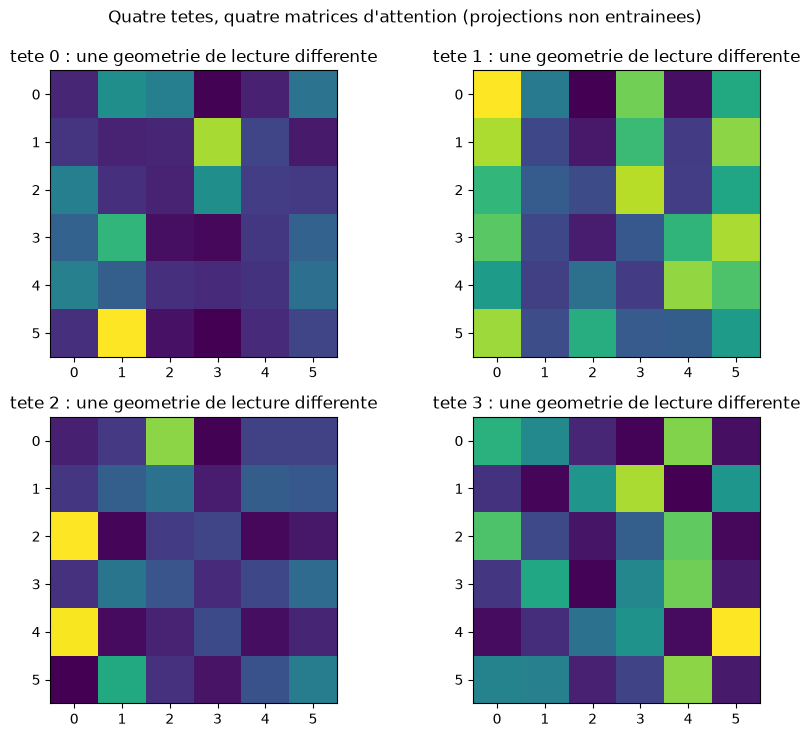

In [7]:
# Multi-tetes from scratch : h regards independants en dimension d/h chacun.
d, h = 24, 4
dh = d // h
rng = np.random.RandomState(1)
Wq, Wk, Wv, Wo = (rng.randn(d, d) / math.sqrt(d) for _ in range(4))

x_toy = rng.randn(T, d)              # "embeddings" des 6 positions de la section 3
matrices_tetes, sorties_tetes = [], []
for t in range(h):
    q = x_toy @ Wq[:, t * dh : (t + 1) * dh]
    k = x_toy @ Wk[:, t * dh : (t + 1) * dh]
    v = x_toy @ Wv[:, t * dh : (t + 1) * dh]
    s = q @ k.T / math.sqrt(dh)
    a = np.exp(s - s.max(-1, keepdims=True))
    a = a / a.sum(-1, keepdims=True)
    matrices_tetes.append(a)
    sorties_tetes.append(a @ v)

sortie_mha = np.concatenate(sorties_tetes, axis=1) @ Wo
print("entree :", x_toy.shape, "-> sortie multi-tetes :", sortie_mha.shape,
      "(concat des 4 tetes puis projection Wo)")

fig, axes = plt.subplots(2, 2, figsize=(9, 7.4))
for t, ax in enumerate(axes.flat):
    ax.imshow(matrices_tetes[t], cmap="viridis")
    ax.set_title(f"tete {t} : une geometrie de lecture differente")
plt.suptitle("Quatre tetes, quatre matrices d'attention (projections non entrainees)", y=0.99)
plt.tight_layout(); plt.show()

### Lecture du résultat

Même séquence, quatre matrices d'attention sans rapport entre elles : chaque tête projette
$Q$, $K$, $V$ dans **son** sous-espace de dimension 6, et le produit scalaire y mesure une
géométrie différente. Ces matrices sont ici arbitraires (projections aléatoires non entraînées)
— on reverra en section 8 celles d'un modèle **entraîné**, qui se spécialisent. La concaténation
rétablit la dimension $d = 24$, et $W_o$ apprend à mélanger les quatre points de vue.

## 5. La preuve d'équivalence : `torch.nn.MultiheadAttention`

Section de vérification, pas de construction : notre multi-têtes réécrit en torch (poids
explicites) contre le module officiel, **aux mêmes poids**. Si les sorties coïncident au niveau
de la précision float32, la quarantaine de lignes ci-dessus est bien celle que la production
exécute.

In [8]:
# PREUVE D'EQUIVALENCE : notre multi-tetes contre torch.nn, aux MEMES poids.
d, h, T2, B2 = 32, 4, 10, 3
torch.manual_seed(7)
x = torch.randn(B2, T2, d)

Wq_t = torch.randn(d, d) / math.sqrt(d)
Wk_t = torch.randn(d, d) / math.sqrt(d)
Wv_t = torch.randn(d, d) / math.sqrt(d)
Wo_t = torch.randn(d, d) / math.sqrt(d)

def mha_maison(x, Wq, Wk, Wv, Wo, h):
    B, T, C = x.shape
    dh = C // h
    q, k, v = x @ Wq, x @ Wk, x @ Wv
    q, k, v = (t.view(B, T, h, dh).transpose(1, 2) for t in (q, k, v))
    poids = (q @ k.transpose(-2, -1) / math.sqrt(dh)).softmax(dim=-1)
    sortie = (poids @ v).transpose(1, 2).reshape(B, T, C)
    return sortie @ Wo

# PIEGE : F.linear (et donc nn.MultiheadAttention) calcule x @ W.T, pas x @ W.
# Nos poids Wq/Wk/Wv/Wo sont au format "x matriciel a droite" : pour les injecter
# dans le module officiel, on copie leur TRANSPOSEE dans in_proj_weight / out_proj.weight.
ref = nn.MultiheadAttention(d, h, bias=False, batch_first=True)
with torch.no_grad():
    ref.in_proj_weight.copy_(torch.cat([Wq_t.T, Wk_t.T, Wv_t.T], dim=0))
    ref.out_proj.weight.copy_(Wo_t.T)

attendu, _ = ref(x, x, x)
notre = mha_maison(x, Wq_t, Wk_t, Wv_t, Wo_t, h)
ecart = (notre - attendu).abs().max().item()
print(f"ecart max maison vs torch.nn : {ecart:.3e} (float32)")
assert torch.allclose(notre, attendu, atol=1e-5), f"equivalence rompue (ecart {ecart:.3e})"
print("EQUIVALENCE PROUVEE : sorties identiques a poids egaux.")

ecart max maison vs torch.nn : 2.384e-07 (float32)
EQUIVALENCE PROUVEE : sorties identiques a poids egaux.


### Lecture du résultat

L'écart maximal est de l'ordre de $10^{-7}$ : rien d'autre que le bruit d'arrondi float32 entre
nos produits matriciels et ceux du module officiel (l'ordre des opérations diffère légèrement,
pas les maths). Cette cellule est le garde-fou du notebook : si une future édition de la section
3 ou 4 cassait la formule, l'assertion échouerait ici — et non silencieusement au §7 sur un
modèle qui apprend mal.

## 6. Le bloc transformer complet

Il reste à assembler : autour de l'attention et du MLP, deux **connexions résiduelles** et deux
**LayerNorm** en style *pré-norme* ($x + f(\mathrm{LN}(x))$). Les résiduelles offrent à la
rétropropagation une autoroute sans transformation — le même rôle que dans 3.1 — et la
pré-norme garde les activations dans une plage stable quelle que soit la profondeur. Le GPT
en entier : embeddings + PE sinusoïdaux, $n$ blocs identiques, LayerNorm final, et une tête de
lecture **liée** à l'embedding (mêmes poids : moins de paramètres, régularisation gratuite).

In [9]:
class BlocTransformer(nn.Module):
    """Pre-norme : LN precede chaque sous-couche, le residuel additionne."""
    def __init__(self, d, mlp=4):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv, self.proj = nn.Linear(d, 3 * d), nn.Linear(d, d)
        self.fc1, self.fc2 = nn.Linear(d, mlp * d), nn.Linear(mlp * d, d)

    def forward(self, x, retour_poids=False):
        B, T, C = x.shape
        h, dh = 4, C // 4
        q, k, v = self.qkv(self.ln1(x)).split(C, dim=2)
        q, k, v = (t.view(B, T, h, dh).transpose(1, 2) for t in (q, k, v))
        scores = q @ k.transpose(-2, -1) / math.sqrt(dh)
        masque = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        poids = scores.masked_fill(masque, float("-inf")).softmax(dim=-1)
        x = x + self.proj((poids @ v).transpose(1, 2).reshape(B, T, C))
        x = x + self.fc2(F.gelu(self.fc1(self.ln2(x))))
        return (x, poids.detach()) if retour_poids else x

class MiniGPT(nn.Module):
    """1,25 M de parametres : embedding lie, PE sinusoidaux, 4 blocs pre-norme."""
    def __init__(self, taille_vocab, d=160, n_blocs=4, ctx=96):
        super().__init__()
        self.emb = nn.Embedding(taille_vocab, d)
        self.ln_f = nn.LayerNorm(d)
        self.tete = nn.Linear(d, taille_vocab, bias=False)
        self.tete.weight = self.emb.weight          # liaison (weight tying)
        pe = torch.tensor(encodage_positionnel(ctx, d), dtype=torch.float32)
        self.register_buffer("pe", pe)
        self.blocs = nn.ModuleList([BlocTransformer(d) for _ in range(n_blocs)])

    def forward(self, idx, retour_poids=False):
        B, T = idx.shape
        x = self.emb(idx) + self.pe[:T]
        poids_b0 = None
        for i, b in enumerate(self.blocs):
            if retour_poids and i == 0:
                x, poids_b0 = b(x, retour_poids=True)
            else:
                x = b(x)
        x = self.ln_f(x)
        logits = self.tete(x)
        return (logits, poids_b0) if retour_poids else logits

# test de forme : logits (batch, contexte, vocab), masque causal deja en place.
# retour_poids est en no_grad cote bloc (lecture seule) : pas de gradient qui coule,
# pas de graph conserve pour la retropropagation de l'entrainement futur.
with torch.no_grad():
    modele_test = MiniGPT(95)
    x_probe = torch.randint(0, 95, (2, 50))
    logits_probe, poids_probe = modele_test(x_probe, retour_poids=True)
    print("logits :", tuple(logits_probe.shape), "| poids bloc 0 :", tuple(poids_probe.shape))
    print("parametres du modele :", sum(p.numel() for p in modele_test.parameters()))
    print("ligne 30 du masque : poids sur le futur =", float(poids_probe[0, :, 30, 31:].sum()))

logits : (2, 50, 95) | poids bloc 0 : (2, 4, 50, 50)
parametres du modele : 1252640
ligne 30 du masque : poids sur le futur = 0.0


### Lecture du résultat

Les logits ont la forme attendue $(B, T, |\mathcal{V}|)$ : pour chaque position, une
distribution sur le vocabulaire. Les poids du bloc 0 ont la forme $(B, h, T, T)$ — une matrice
d'attention par tête, par élément du lot. Et la dernière ligne vérifie le masque **en
exécution** : la position 30 ne met strictement aucun poids sur les positions 31 et au-delà
(somme exactement nulle). Le compte de paramètres (~1,25 M pour un vocabulaire de 95) sera
recalculé sur le vocabulaire réel à la section suivante.

## 7. Le mini-GPT : apprendre Maupassant, caractère par caractère

Le corpus : les premières pages du *Horla* (Guy de Maupassant, 1887 — domaine public), sous
forme de journal intime en français. Le texte est **embarqué dans le notebook** pour qu'il soit
autonome (l'intégrale vit dans le dépôt : `GenAI/Audio/04-Applications/datasets/le_horla_1887.txt`).

La tâche est celle de la section 3, mais apprise au lieu d'être posée : à chaque position,
prédire le **caractère suivant** vu tout ce qui précède (masque causal). Un modèle de 1,25 M de
paramètres — 10 000 fois plus petit qu'un Llama 7B — suffit pour apprendre l'orthographe
française, la ponctuation du journal et le style de Maupassant.

In [10]:
# Corpus : extrait du Horla embarque ( coupe a la frontiere de phrase vers 60 000 caracteres).
CORPUS = (
    "GUY DE MAUPASSANT\n\nLe Horla\n\n\n\n1887\n\n\n\n\nLE HORLA\n\n\n\n\n_8 mai._--Quelle journée admirable!"
    " J'ai passé toute la matinée étendu sur\nl'herbe, devant ma maison, sous l'énorme platane"
    " qui la couvre, l'abrite et\nl'ombrage tout entière. J'aime ce pays, et j'aime y vivre pa"
    "rce que j'y ai\nmes racines, ces profondes et délicates racines, qui attachent un homme à"
    "\nla terre où sont nés et morts ses aïeux, qui l'attachent à ce qu'on pense\net à ce qu'on"
    " mange, aux usages comme aux nourritures, aux locutions\nlocales, aux intonations des pay"
    "sans, aux odeurs du sol, des villages et de\nl'air lui-même.\n\nJ'aime ma maison où j'ai gr"
    "andi. De mes fenêtres, je vois la Seine qui\ncoule, le long de mon jardin, derrière la ro"
    "ute, presque chez moi, la\ngrande et large Seine, qui va de Rouen au Havre, couverte de b"
    "ateaux qui\npassent.\n\nA gauche, là-bas, Rouen, la vaste ville aux toits bleus, sous le pe"
    "uple\npointu des clochers gothiques. Ils sont innombrables, frêles ou larges,\ndominés par"
    " la flèche de fonte de la cathédrale, et pleins de cloches qui\nsonnent dans l'air bleu d"
    "es belles matinées, jetant jusqu'à moi leur doux\net lointain bourdonnement de fer, leur "
    "chant d'airain que la brise\nm'apporte, tantôt plus fort et tantôt plus affaibli, suivant"
    " qu'elle\ns'éveille ou s'assoupit.\n\nComme il faisait bon ce matin!\n\nVers onze heures, un "
    "long convoi de navires, traînés par un remorqueur,\ngros comme une mouche, et qui râlait "
    "de peine en vomissant une fumée\népaisse, défila devant ma grille.\n\nAprès deux goëlettes "
    "anglaises, dont le pavillon rouge ondoyait sur le\nciel, venait un superbe trois-mats bré"
    "silien, tout blanc, admirablement\npropre et luisant. Je le saluai, je ne sais pourquoi, "
    "tant ce navire me fit\nplaisir à voir.\n\n_12 mai_.--J'ai un peu de fièvre depuis quelques "
    "jours; je me sens\nsouffrant, ou plutôt je me sens triste.\n\nD'où viennent ces influences "
    "mystérieuses qui changent en découragement\nnotre bonheur et notre confiance en détresse."
    " On dirait que l'air, l'air\ninvisible est plein d'inconnaissables Puissances, dont nous "
    "subissons les\nvoisinages mystérieux. Je m'éveille plein de gaîté, avec des envies de\ncha"
    "nter dans la gorge.--Pourquoi?--Je descends le long de l'eau; et\nsoudain, après une cour"
    "te promenade, je rentre désolé, comme si quelque\nmalheur m'attendait chez moi.--Pourquoi"
    "?--Est-ce un frisson de froid qui,\nfrôlant ma peau, a ébranlé mes nerfs et assombri mon "
    "âme? Est-ce la forme\ndes nuages, ou la couleur du jour, la couleur des choses, si variab"
    "le, qui,\npassant par mes yeux, a troublé ma pensée? Sait-on? Tout ce qui nous\nentoure, t"
    "out ce que nous voyons sans le regarder, tout ce que nous frôlons\nsans le connaître, tou"
    "t ce que nous touchons sans le palper, tout ce que\nnous rencontrons sans le distinguer, "
    "a sur nous, sur nos organes et, par\neux, sur nos idées, sur notre coeur lui-même, des ef"
    "fets rapides,\nsurprenants et inexplicables?\n\nComme il est profond, ce mystère de l'Invis"
    "ible! Nous ne le pouvons sonder\navec nos sens misérables, avec nos yeux qui ne savent ap"
    "ercevoir ni le trop\npetit, ni le trop grand, ni le trop près, ni le trop loin, ni les ha"
    "bitants\nd'une étoile, ni les habitants d'une goutte d'eau... avec nos oreilles qui\nnous "
    "trompent, car elles nous transmettent les vibrations de l'air en notes\nsonores. Elles so"
    "nt des fées qui font ce miracle de changer en bruit ce\nmouvement et par cette métamorpho"
    "se donnent naissance à la musique, qui\nrend chantante l'agitation muette de la nature..."
    " avec notre odorat, plus\nfaible que celui du chien... avec notre goût, qui peut à peine "
    "discerner\nl'âge d'un vin!\n\nAh! si nous avions d'autres organes qui accompliraient en not"
    "re faveur\nd'autres miracles, que de choses nous pourrions découvrir encore autour de\nnou"
    "s!\n\n_16 mai_.--Je suis malade, décidément! Je me portais si bien le mois\ndernier! J'ai l"
    "a fièvre, une fièvre atroce, ou plutôt un énervement\nfiévreux, qui rend mon âme aussi so"
    "uffrante que mon corps. J'ai sans cesse\ncette sensation affreuse d'un danger menaçant, c"
    "ette appréhension d'un\nmalheur qui vient ou de la mort qui approche, ce pressentiment qu"
    "i est sans\ndoute l'atteinte d'un mal encore inconnu, germant dans le sang et dans la\ncha"
    "ir.\n\n_18 mai_.--Je viens d'aller consulter mon médecin, car je ne pouvais plus\ndormir. I"
    "l m'a trouvé le pouls rapide, l'oeil dilaté, les nerfs vibrants,\nmais sans aucun symptôm"
    "e alarmant. Je dois me soumettre aux douches et\nboire du bromure de potassium.\n\n_25 mai_"
    ".--Aucun changement! Mon état, vraiment, est bizarre. A mesure\nqu'approche le soir, une "
    "inquiétude incompréhensible m'envahit, comme si la\nnuit cachait pour moi une menace terr"
    "ible. Je dîne vite, puis j'essaye de\nlire; mais je ne comprends pas les mots; je disting"
    "ue à peine les lettres.\nJe marche alors dans mon salon de long en large, sous l'oppressi"
    "on d'une\ncrainte confuse et irrésistible, la crainte du sommeil et la crainte du\nlit.\n\nV"
    "ers dix heures, je monte dans ma chambre. A peine entré, je donne deux\ntours de clef, et"
    " je pousse les verrous; j'ai peur... de quoi?... Je ne\nredoutais rien jusqu'ici... j'ouv"
    "re mes armoires, je regarde sous mon lit;\nj'écoute... j'écoute... quoi?... Est-ce étrang"
    "e qu'un simple malaise, un\ntrouble de la circulation peut-être, l'irritation d'un filet "
    "nerveux, un\npeu de congestion, une toute petite perturbation dans le fonctionnement si\ni"
    "mparfait et si délicat de notre machine vivante, puisse faire un\nmélancolique du plus jo"
    "yeux des hommes, et un poltron du plus brave? Puis,\nje me couche, et j'attends le sommei"
    "l comme on attendrait le bourreau. Je\nl'attends avec l'épouvante de sa venue; et mon coe"
    "ur bat, et mes jambes\nfrémissent; et tout mon corps tressaille dans la chaleur des draps"
    ",\njusqu'au moment où je tombe tout à coup dans le repos, comme on tomberait\npour s'y noy"
    "er, dans un gouffre d'eau stagnante. Je ne le sens pas venir,\ncomme autrefois, ce sommei"
    "l perfide, caché près de moi, qui me guette, qui\nva me saisir par la tête, me fermer les"
    " yeux, m'anéantir.\n\nJe dors--longtemps--deux ou trois heures--puis un rêve--non--un cauc"
    "hemar\nm'étreint. Je sens bien que je suis couché et que je dors,... je le sens et\nje le "
    "sais... et je sens aussi que quelqu'un s'approche de moi, me regarde,\nme palpe, monte su"
    "r mon lit, s'agenouille sur ma poitrine, me prend le cou\nentre ses mains et serre... ser"
    "re... de toute sa force pour m'étrangler.\n\nMoi, je me débats, lié par cette impuissance "
    "atroce, qui nous paralyse dans\nles songes; je veux crier,--je ne peux pas;--je veux remu"
    "er,--je ne peux\npas;--j'essaye, avec des efforts affreux, en haletant, de me tourner, de"
    "\nrejeter cet être qui m'écrase et qui m'étouffe,--je ne peux pas!\n\nEt soudain, je m'évei"
    "lle, affolé, couvert de sueur. J'allume une bougie. Je\nsuis seul.\n\nAprès cette crise, qu"
    "i se renouvelle toutes les nuits, je dors enfin, avec\ncalme, jusqu'à l'aurore.\n\n_2 juin_"
    ".--Mon état s'est encore aggravé. Qu'ai-je donc? Le bromure n'y\nfait rien; les douches n"
    "'y font rien. Tantôt, pour fatiguer mon corps, si\nlas pourtant, j'allai faire un tour da"
    "ns la forêt de Roumare. Je crus\nd'abord que l'air frais, léger et doux, plein d'odeur d'"
    "herbes et de\nfeuilles, me versait aux veines un sang nouveau, au coeur une énergie\nnouve"
    "lle. Je pris une grande avenue de chasse, puis je tournai vers La\nBouille, par une allée"
    " étroite, entre deux armées d'arbres démesurément\nhauts qui mettaient un toit vert, épai"
    "s, presque noir, entre le ciel et\nmoi.\n\nUn frisson me saisit soudain, non pas un frisson"
    " de froid, mais un étrange\nfrisson d'angoisse.\n\nJe hâtai le pas, inquiet d'être seul dan"
    "s ce bois, apeuré sans raison,\nstupidement, par la profonde solitude. Tout à coup, il me"
    " sembla que\nj'étais suivi, qu'on marchait sur mes talons, tout près, tout près, à me\ntou"
    "cher.\n\nJe me retournai brusquement. J'étais seul. Je ne vis derrière moi que la\ndroite e"
    "t large allée, vide, haute, redoutablement vide; et de l'autre côté\nelle s'étendait auss"
    "i à perte de vue, toute pareille, effrayante.\n\nJe fermai les yeux. Pourquoi? Et je me mi"
    "s à tourner sur un talon, très\nvite, comme une toupie. Je faillis tomber; je rouvris les"
    " yeux; les arbres\ndansaient; la terre flottait; je dus m'asseoir. Puis, ah! je ne savais"
    " plus\npar où j'étais venu! Bizarre idée! Bizarre! Bizarre idée! Je ne savais plus\ndu tou"
    "t. Je partis par le côté qui se trouvait à ma droite, et je revins\ndans l'avenue qui m'a"
    "vait amené au milieu de la forêt.\n\n_3 juin_.--La nuit a été horrible. Je vais m'absenter"
    " pendant quelques\nsemaines. Un petit voyage, sans doute, me remettra.\n\n_2 juillet_.--Je "
    "rentre. Je suis guéri. J'ai fait d'ailleurs une excursion\ncharmante. J'ai visité le mont"
    " Saint-Michel que je ne connaissais pas.\n\nQuelle vision, quand on arrive, comme moi, à A"
    "vranches, vers la fin du\njour! La ville est sur une colline; et on me conduisit dans le "
    "jardin\npublic, au bout de la cité. Je poussai un cri d'étonnement. Une baie\ndémesurée s'"
    "étendait devant moi, à perte de vue, entre deux côtes écartées\nse perdant au loin dans l"
    "es brumes; et au milieu de cette immense baie\njaune, sous un ciel d'or et de clarté, s'é"
    "levait sombre et pointu un mont\nétrange, au milieu des sables. Le soleil venait de dispa"
    "raître, et sur\nl'horizon encore flamboyant se dessinait le profil de ce fantastique roch"
    "er\nqui porte sur son sommet un fantastique monument.\n\nDès l'aurore, j'allai vers lui. La"
    " mer était basse, comme la veille au\nsoir, et je regardais se dresser devant moi, à mesu"
    "re que j'approchais\nd'elle, la surprenante abbaye. Après plusieurs heures de marche,\nj'a"
    "tteignis l'énorme bloc de pierres qui porte la petite cité dominée par\nla grande église."
    " Ayant gravi la rue étroite et rapide, j'entrai dans la\nplus admirable demeure gothique "
    "construite pour Dieu sur la terre, vaste\ncomme une ville, pleine de salles basses écrasé"
    "es sous des voûtes et de\nhautes galeries que soutiennent de frêles colonnes. J'entrai da"
    "ns ce\ngigantesque bijou de granit, aussi léger qu'une dentelle, couvert de tours,\nde sve"
    "ltes clochetons, où montent des escaliers tordus, et qui lancent dans\nle ciel bleu des j"
    "ours, dans le ciel noir des nuits, leurs têtes bizarres\nhérissées de chimères, de diable"
    "s, de bêtes fantastiques, de fleurs\nmonstrueuses, et reliés l'un à l'autre par de fines "
    "arches ouvragées.\n\nQuand je fus sur le sommet, je dis au moine qui m'accompagnait: «Mon "
    "père,\ncomme vous devez être bien ici!»\n\nIl répondit: «Il y a beaucoup de vent, Monsieur»"
    "; et nous nous mîmes à\ncauser en regardant monter la mer, qui courait sur le sable et le"
    " couvrait\nd'une cuirasse d'acier.\n\nEt le moine me conta des histoires, toutes les vieill"
    "es histoires de ce\nlieu, des légendes, toujours des légendes.\n\nUne d'elles me frappa bea"
    "ucoup. Les gens du pays, ceux du mont, prétendent\nqu'on entend parler la nuit dans les s"
    "ables, puis qu'on entend bêler deux\nchèvres, l'une avec une voix forte, l'autre avec une"
    " voix faible. Les\nincrédules affirment que ce sont les cris des oiseaux de mer, qui\nress"
    "emblent tantôt à des bêlements, et tantôt à des plaintes humaines; mais\nles pêcheurs att"
    "ardés jurent avoir rencontré, rôdant sur les dunes, entre\ndeux marées, autour de la peti"
    "te ville jetée ainsi loin du monde, un vieux\nberger, dont on ne voit jamais la tête couv"
    "erte de son manteau, et qui\nconduit, en marchant devant eux, un bouc à figure d'homme et"
    " une chèvre à\nfigure de femme, tous deux avec de longs cheveux blancs et parlant sans\nce"
    "sse, se querellant dans une langue inconnue, puis cessant soudain de\ncrier pour bêler de"
    " toute leur force.\n\nJe dis au moine: «Y croyez-vous?»\n\nIl murmura: «Je ne sais pas.»\n\nJe"
    " repris: «S'il existait sur la terre d'autres êtres que nous, comment ne\nles connaîtrion"
    "s-nous point depuis longtemps; comment ne les auriez-vous\npas vus, vous? comment ne les "
    "aurais-je pas vus, moi?»\n\nIl répondit: «Est-ce que nous voyons la cent-millième partie d"
    "e ce qui\nexiste? Tenez, voici le vent, qui est la plus grande force de la nature,\nqui re"
    "nverse les hommes, abat les édifices, déracine les arbres, soulève la\nmer en montagnes d"
    "'eau, détruit les falaises, et jette aux brisants les\ngrands navires, le vent qui tue, q"
    "ui siffle, qui gémit, qui\nmugit,--l'avez-vous vu, et pouvez-vous le voir? Il existe, pou"
    "rtant.»\n\nJe me tus devant ce simple raisonnement. Cet homme était un sage ou\npeut-être u"
    "n sot. Je ne l'aurais pu affirmer au juste; mais je me tus. Ce\nqu'il disait là, je l'ava"
    "is pensé souvent.\n\n_3 juillet_.--J'ai mal dormi; certes, il y a ici une influence fiévre"
    "use,\ncar mon cocher souffre du même mal que moi. En rentrant hier, j'avais\nremarqué sa p"
    "âleur singulière. Je lui demandai:\n\n--Qu'est-ce que vous avez, Jean?\n\n--J'ai que je ne p"
    "eux plus me reposer, Monsieur, ce sont mes nuits qui\nmangent mes jours. Depuis le départ"
    " de Monsieur, cela me tient comme un\nsort.\n\nLes autres domestiques vont bien cependant, "
    "mais j'ai grand peur d'être\nrepris, moi.\n\n_4 juillet_.--Décidément, je suis repris. Mes "
    "cauchemars anciens\nreviennent. Cette nuit, j'ai senti quelqu'un accroupi sur moi, et qui"
    ", sa\nbouche sur la mienne, buvait ma vie entre mes lèvres. Oui, il la puisait\ndans ma go"
    "rge, comme aurait fait une sangsue. Puis il s'est levé, repu, et\nmoi je me suis réveillé"
    ", tellement meurtri, brisé, anéanti, que je ne\npouvais plus remuer. Si cela continue enc"
    "ore quelques jours, je repartirai\ncertainement.\n\n_5 juillet_.--Ai-je perdu la raison? Ce"
    " qui s'est passé, ce que j'ai vu la\nnuit dernière est tellement étrange, que ma tête s'é"
    "gare quand j'y songe!\n\nComme je le fais maintenant chaque soir, j'avais fermé ma porte à"
    " clef;\npuis, ayant soif, je bus un demi-verre d'eau, et je remarquai par hasard\nque ma c"
    "arafe était pleine jusqu'au bouchon de cristal.\n\nJe me couchai ensuite et je tombai dans"
    " un de mes sommeils épouvantables,\ndont je fus tiré au bout de deux heures environ par u"
    "ne secousse plus\naffreuse encore.\n\nFigurez-vous un homme qui dort, qu'on assassine, et q"
    "ui se réveille avec un\ncouteau dans le poumon, et qui râle, couvert de sang, et qui ne p"
    "eut plus\nrespirer, et qui va mourir, et qui ne comprend pas--voilà.\n\nAyant enfin reconqu"
    "is ma raison, j'eus soif de nouveau; j'allumai une\nbougie et j'allai vers la table où ét"
    "ait posée ma carafe. Je la soulevai en\nla penchant sur mon verre; rien ne coula.--Elle é"
    "tait vide! Elle était vide\ncomplètement! D'abord, je n'y compris rien; puis, tout à coup"
    ", je ressentis\nune émotion si terrible, que je dus m'asseoir, ou plutôt, que je tombai s"
    "ur\nune chaise! puis, je me redressai d'un saut pour regarder autour de moi!\npuis je me r"
    "assis, éperdu d'étonnement et de peur, devant le cristal\ntransparent! Je le contemplais "
    "avec des yeux fixes, cherchant à deviner.\nMes mains tremblaient! On avait donc bu cette "
    "eau? Qui? Moi? moi, sans\ndoute? Ce ne pouvait être que moi? Alors, j'étais somnambule, j"
    "e vivais,\nsans le savoir, de cette double vie mystérieuse qui fait douter s'il y a\ndeux "
    "êtres en nous, ou si un être étranger, inconnaissable et invisible,\nanime, par moments, "
    "quand notre âme est engourdie, notre corps captif qui\nobéit à cet autre, comme à nous-mê"
    "mes, plus qu'à nous-mêmes.\n\nAh! qui comprendra mon angoisse abominable? Qui comprendra l"
    "'émotion d'un\nhomme, sain d'esprit, bien éveillé, plein de raison et qui regarde\népouvan"
    "té, à travers le verre d'une carafe, un peu d'eau disparue pendant\nqu'il a dormi! Et je "
    "restai là jusqu'au jour, sans oser regagner mon lit.\n\n_6 juillet_.--Je deviens fou. On a"
    " encore bu toute ma carafe cette\nnuit;--ou plutôt, je l'ai bue!\n\nMais, est-ce moi? Est-c"
    "e moi? Qui serait-ce? Qui? Oh! mon Dieu! Je deviens\nfou? Qui me sauvera?\n\n_10 juillet_.-"
    "-Je viens de faire des épreuves surprenantes.\n\nDécidément, je suis fou! Et pourtant!\n\nLe"
    " 6 juillet, avant de me coucher, j'ai placé sur ma table du vin, du lait,\nde l'eau, du p"
    "ain et des fraises.\n\nOn a bu--j'ai bu--toute l'eau, et un peu de lait. On n'a touché ni "
    "au vin,\nni au pain, ni aux fraises.\n\nLe 7 juillet, j'ai renouvelé la même épreuve, qui a"
    " donné le même résultat.\n\nLe 8 juillet, j'ai supprimé l'eau et le lait. On n'a touché à "
    "rien.\n\nLe 9 juillet enfin, j'ai remis sur ma table l'eau et le lait seulement, en\nayant "
    "soin d'envelopper les carafes en des linges de mousseline blanche et\nde ficeler les bouc"
    "hons. Puis, j'ai frotté mes lèvres, ma barbe, mes mains\navec de la mine de plomb, et je "
    "me suis couché.\n\nL'invincible sommeil m'a saisi, suivi bientôt de l'atroce réveil. Je\nn'"
    "avais point remué; mes draps eux-mêmes ne portaient pas de taches. Je\nm'élançai vers ma "
    "table. Les linges enfermant les bouteilles étaient\ndemeurés immaculés. Je déliai les cor"
    "dons, en palpitant de crainte. On\navait bu toute l'eau! on avait bu tout le lait! Ah! mo"
    "n Dieu!...\n\nJe vais partir tout à l'heure pour Paris.\n\n_12 juillet_.--Paris. J'avais don"
    "c perdu la tête les jours derniers! J'ai\ndû être le jouet de mon imagination énervée, à "
    "moins que je ne sois\nvraiment somnambule, ou que j'aie subi une de ces influences consta"
    "tées,\nmais inexplicables jusqu'ici, qu'on appelle suggestions. En tout cas, mon\naffoleme"
    "nt touchait à la démence, et vingt-quatre heures de Paris ont suffi\npour me remettre d'a"
    "plomb.\n\nHier, après des courses et des visites, qui m'ont fait passer dans l'âme de\nl'ai"
    "r nouveau et vivifiant, j'ai fini ma soirée au Théâtre-Français. On y\njouait une pièce d"
    "'Alexandre Dumas fils; et cet esprit alerte et puissant a\nachevé de me guérir. Certes, l"
    "a solitude est dangereuse pour les\nintelligences qui travaillent. Il nous faut, autour d"
    "e nous, des hommes qui\npensent et qui parlent. Quand nous sommes seuls longtemps, nous p"
    "euplons le\nvide de fantômes.\n\nJe suis rentré à l'hôtel très gai, par les boulevards. Au "
    "coudoiement de la\nfoule, je songeais, non sans ironie, à mes terreurs, à mes supposition"
    "s de\nl'autre semaine, car j'ai cru, oui, j'ai cru qu'un être invisible habitait\nsous mon"
    " toit. Comme notre tête est faible et s'effare, et s'égare vite,\ndès qu'un petit fait in"
    "compréhensible nous frappe!\n\nAu lieu de conclure par ces simples mots: «Je ne comprends "
    "pas parce que la\ncause m'échappe», nous imaginons aussitôt des mystères effrayants et de"
    "s\npuissances surnaturelles.\n\n_14 juillet_.--Fête de la République. Je me suis promené pa"
    "r les rues. Les\npétards et les drapeaux m'amusaient comme un enfant. C'est pourtant fort"
    "\nbête d'être joyeux, à date fixe, par décret du gouvernement. Le peuple est\nun troupeau "
    "imbécile, tantôt stupidement patient et tantôt férocement\nrévolté. On lui dit: «Amuse-to"
    "i.» Il s'amuse. On lui dit: «Va te battre\navec le voisin.» Il va se battre. On lui dit: "
    "«Vote pour l'Empereur.» Il\nvote pour l'Empereur. Puis, on lui dit: «Vote pour la Républi"
    "que.» Et il\nvote pour la République.\n\nCeux qui le dirigent sont aussi sots; mais au lieu"
    " d'obéir à des hommes,\nils obéissent à des principes, lesquels ne peuvent être que niais"
    ", stériles\net faux, par cela même qu'ils sont des principes, c'est-à-dire des idées\nrépu"
    "tées certaines et immuables, en ce monde où l'on n'est sûr de rien,\npuisque la lumière e"
    "st une illusion, puisque le bruit est une illusion.\n\n_16 juillet_.--J'ai vu hier des cho"
    "ses qui m'ont beaucoup troublé.\n\nJe dînais chez ma cousine, Mme Sablé, dont le mari comm"
    "ande le 76e\nchasseurs à Limoges. Je me trouvais chez elle avec deux jeunes femmes, dont\n"
    "l'une a épousé un médecin, le docteur Parent, qui s'occupe beaucoup des\nmaladies nerveus"
    "es et des manifestations extraordinaires auxquelles donnent\nlieu en ce moment les expéri"
    "ences sur l'hypnotisme et la suggestion.\n\nIl nous raconta longuement les résultats prodi"
    "gieux obtenus par des savants\nanglais et par les médecins de l'école de Nancy.\n\nLes fait"
    "s qu'il avança me parurent tellement bizarres, que je me déclarai\ntout à fait incrédule."
    "\n\n«Nous sommes, affirmait-il, sur le point de découvrir un des plus\nimportants secrets d"
    "e la nature, je veux dire, un de ses plus importants\nsecrets sur cette terre; car elle e"
    "n a certes d'autrement importants,\nlà-bas, dans les étoiles. Depuis que l'homme pense, d"
    "epuis qu'il sait dire\net écrire sa pensée, il se sent frôlé par un mystère impénétrable "
    "pour ses\nsens grossiers et imparfaits, et il tâche de suppléer, par l'effort de son\ninte"
    "lligence, à l'impuissance de ses organes. Quand cette intelligence\ndemeurait encore à l'"
    "état rudimentaire, cette hantise des phénomènes\ninvisibles a pris des formes banalement "
    "effrayantes. De là sont nées les\ncroyances populaires au surnaturel, les légendes des es"
    "prits rôdeurs, des\nfées, des gnomes, des revenants, je dirai même la légende de Dieu, ca"
    "r nos\nconceptions de l'ouvrier-créateur, de quelque religion qu'elles nous\nviennent, son"
    "t bien les inventions les plus médiocres, les plus stupides,\nles plus inacceptables sort"
    "ies du cerveau apeuré des créatures. Rien de\nplus vrai que cette parole de Voltaire. «Di"
    "eu a fait l'homme à son image,\nmais l'homme le lui a bien rendu.»\n\n«Mais, depuis un peu "
    "plus d'un siècle, on semble pressentir quelque chose\nde nouveau. Mesmer et quelques autr"
    "es nous ont mis sur une voie inattendue,\net nous sommes arrivés vraiment, depuis quatre "
    "ou cinq ans surtout, à des\nrésultats surprenants.»\n\nMa cousine, très incrédule aussi, so"
    "uriait. Le docteur Parent lui\ndit:--Voulez-vous que j'essaie de vous endormir, Madame?\n\n"
    "--Oui, je veux bien.\n\nElle s'assit dans un fauteuil et il commença à la regarder fixemen"
    "t en la\nfascinant. Moi, je me sentis soudain un peu troublé, le coeur battant, la\ngorge "
    "serrée. Je voyais les yeux de Mme Sablé s'alourdir, sa bouche se\ncrisper, sa poitrine ha"
    "leter.\n\nAu bout de dix minutes, elle dormait.\n\n--Mettez-vous derrière elle, dit le médec"
    "in.\n\nEt je m'assis derrière elle. Il lui plaça entre les mains une carte de\nvisite en lu"
    "i disant: «Ceci est un miroir; que voyez-vous dedans?»\n\nElle répondit:\n\n--Je vois mon co"
    "usin.\n\n--Que fait-il?\n\n--Il se tord la moustache.\n\n--Et maintenant?\n\n--Il tire de sa poc"
    "he une photographie.\n\n--Quelle est cette photographie?\n\n--La sienne.\n\nC'était vrai! Et c"
    "ette photographie venait de m'être livrée, le soir même,\nà l'hôtel.\n\n--Comment est-il su"
    "r ce portrait?\n\n--Il se tient debout avec son chapeau à la main.\n\nDonc elle voyait dans "
    "cette carte, dans ce carton blanc, comme elle eût vu\ndans une glace.\n\nLes jeunes femmes,"
    " épouvantées, disaient: «Assez! Assez! Assez!»\n\nMais le docteur ordonna: «Vous vous lève"
    "rez demain à huit heures; puis vous\nirez trouver à son hôtel votre cousin, et vous le su"
    "pplierez de vous prêter\ncinq mille francs que votre mari vous demande et qu'il vous récl"
    "amera à son\nprochain voyage.»\n\nPuis il la réveilla.\n\nEn rentrant à l'hôtel, je songeais "
    "à cette curieuse séance et des doutes\nm'assaillirent, non point sur l'absolue, sur l'ins"
    "oupçonnable bonne foi de\nma cousine, que je connaissais comme une soeur, depuis l'enfanc"
    "e, mais sur\nune supercherie possible du docteur. Ne dissimulait-il pas dans sa main une\n"
    "glace qu'il montrait à la jeune femme endormie, en même temps que sa carte\nde visite? Le"
    "s prestidigitateurs de profession font des choses autrement\nsingulières.\n\nJe rentrai don"
    "c et je me couchai.\n\nOr, ce matin, vers huit heures et demie, je fus réveillé par mon va"
    "let de\nchambre, qui me dit:\n\n--C'est Mme Sablé qui demande à parler à Monsieur tout de s"
    "uite.\n\nJe m'habillai à la hâte et je la reçus.\n\nElle s'assit fort troublée, les yeux bai"
    "ssés, et, sans lever son voile,\nelle me dit:\n\n--Mon cher cousin, j'ai un gros service à "
    "vous demander.\n\n--Lequel, ma cousine?\n\n--Cela me gêne beaucoup de vous le dire, et pourt"
    "ant, il le faut. J'ai\nbesoin, absolument besoin, de cinq mille francs.\n\n--Allons donc, v"
    "ous?\n\n--Oui, moi, ou plutôt mon mari, qui me charge de les trouver.\n\nJ'étais tellement s"
    "tupéfait, que je balbutiais mes réponses. Je me\ndemandais si vraiment elle ne s'était pa"
    "s moquée de moi avec le docteur\nParent, si ce n'était pas là une simple farce préparée d"
    "'avance et fort\nbien jouée.\n\nMais, en la regardant avec attention, tous mes doutes se di"
    "ssipèrent. Elle\ntremblait d'angoisse, tant cette démarche lui était douloureuse, et je\nc"
    "ompris qu'elle avait la gorge pleine de sanglots.\n\nJe la savais fort riche et je repris:"
    "\n\n--Comment! votre mari n'a pas cinq mille francs à sa disposition! Voyons\nréfléchissez."
    " Êtes-vous sûre qu'il vous a chargée de me les demander?\n\nElle hésita quelques secondes "
    "comme si elle eût fait un grand effort pour\nchercher dans son souvenir, puis elle répond"
    "it:\n\n--Oui..., oui... j'en suis sûre.\n\n--Il vous a écrit?\n\nElle hésita encore, réfléchis"
    "sant. Je devinai le travail torturant de sa\npensée. Elle ne savait pas. Elle savait seul"
    "ement qu'elle devait\nm'emprunter cinq mille francs pour son mari. Donc elle osa mentir.\n"
    "\n--Oui, il m'a écrit.\n\n--Quand donc? Vous ne m'avez parlé de rien, hier.\n\n--J'ai reçu sa"
    " lettre ce matin.\n\n--Pouvez-vous me la montrer?\n\n--Non... non... non... elle contenait d"
    "es choses intimes... trop\npersonnelles... je l'ai... je l'ai brûlée.\n\n--Alors, c'est que"
    " votre mari fait des dettes.\n\nElle hésita encore, puis murmura:\n\n--Je ne sais pas.\n\nJe d"
    "éclarai brusquement:\n\n--C'est que je ne puis disposer de cinq mille francs en ce moment,"
    " ma chère\ncousine.\n\nElle poussa une sorte de cri de souffrance.\n\n--Oh! oh! je vous en pr"
    "ie, je vous en prie, trouvez-les...\n\nElle s'exaltait, joignait les mains comme si elle m"
    "'eût prié! J'entendais\nsa voix changer de ton; elle pleurait et bégayait, harcelée, domi"
    "née par\nl'ordre irrésistible qu'elle avait reçu.\n\n--Oh! oh! je vous en supplie... si vou"
    "s saviez comme je souffre... il me\nles faut aujourd'hui.\n\nJ'eus pitié d'elle.\n\n--Vous le"
    "s aurez tantôt, je vous le jure.\n\nElle s'écria:\n\n--Oh! merci! merci! Que vous êtes bon.\n"
    "\nJe repris:--Vous rappelez-vous ce qui s'est passé hier soir chez vous?\n\n--Oui.\n\n--Vous "
    "rappelez-vous que le docteur Parent vous a endormie?\n\n--Oui.\n\n--Eh! bien, il vous a ordo"
    "nné de venir m'emprunter ce matin cinq mille\nfrancs, et vous obéissez en ce moment à cet"
    "te suggestion.\n\nElle réfléchit quelques secondes et répondit:\n\n--Puisque c'est mon mari "
    "qui les demande.\n\nPendant une heure, j'essayai de la convaincre, mais je n'y pus parveni"
    "r.\n\nQuand elle fui partie, je courus chez le docteur. Il allait sortir; et il\nm'écouta e"
    "n souriant. Puis il dit:\n\n--Croyez-vous maintenant?\n\n--Oui, il le faut bien.\n\n--Allons c"
    "hez votre parente.\n\nElle sommeillait déjà sur une chaise longue, accablée de fatigue. Le"
    "\nmédecin lui prit le pouls, la regarda quelque temps, une main levée vers\nses yeux qu'el"
    "le ferma peu à peu sous l'effort insoutenable de cette\npuissance magnétique.\n\nQuand elle"
    " fut endormie:\n\n--Votre mari n'a plus besoin de cinq mille francs! Vous allez donc oubli"
    "er\nque vous avez prié votre cousin de vous les prêter, et, s'il vous parle de\ncela, vous"
    " ne comprendrez pas.\n\nPuis il la réveilla. Je tirai de ma poche un portefeuille:\n\n--Voic"
    "i, ma chère cousine, ce que vous m'avez demandé ce matin.\n\nElle fut tellement surprise q"
    "ue je n'osai pas insister. J'essayai cependant\nde ranimer sa mémoire, mais elle nia avec"
    " force, crut que je me moquais\nd'elle, et faillit, à la fin, se fâcher.\n\n       *       "
    "*       *       *       *\n\nVoilà! je viens de rentrer; et je n'ai pu déjeuner, tant cett"
    "e expérience\nm'a bouleversé.\n\n_19 juillet_.--Beaucoup de personnes à qui j'ai raconté ce"
    "tte aventure se\nsont moquées de moi. Je ne sais plus que penser. Le sage dit: Peut-être?"
    "\n\n_21 juillet_.--J'ai été dîner à Bougival, puis j'ai passé la soirée au bal\ndes canotie"
    "rs. Décidément, tout dépend des lieux et des milieux. Croire au\nsurnaturel dans l'île de"
    " la Grenouillière, serait le comble de la folie...\nmais au sommet du mont Saint-Michel?."
    ".. mais dans les Indes? Nous subissons\neffroyablement l'influence de ce qui nous entoure"
    ". Je rentrerai chez moi la\nsemaine prochaine.\n\n_30 juillet_.--Je suis revenu dans ma mai"
    "son depuis hier. Tout va bien.\n\n_2 août_.--Rien de nouveau; il fait un temps superbe. Je"
    " passe mes journées\nà regarder couler la Seine.\n\n_4 août_.--Querelles parmi mes domestiq"
    "ues. Ils prétendent qu'on casse les\nverres, la nuit, dans les armoires. Le valet de cham"
    "bre accuse la\ncuisinière, qui accuse la lingère, qui accuse les deux autres. Quel est le"
    "\ncoupable? Bien fin qui le dirait?\n\n_6 août_.--Cette fois, je ne suis pas fou. J'ai vu.."
    ". j'ai vu... j'ai\nvu!... Je ne puis plus douter... j'ai vu!... J'ai encore froid jusque "
    "dans\nles ongles... j'ai encore peur jusque dans les moelles... j'ai vu!...\n\nJe me promen"
    "ais à deux heures, en plein soleil, dans mon parterre de\nrosiers... dans l'allée des ros"
    "iers d'automne qui commencent à fleurir.\n\nComme je m'arrêtais à regarder un _géant des b"
    "atailles_, qui portait trois\nfleurs magnifiques, je vis, je vis distinctement, tout près"
    " de moi, la tige\nd'une de ces roses se plier, comme si une main invisible l'eût tordue, "
    "puis\nse casser comme si cette main l'eût cueillie! Puis la fleur s'éleva,\nsuivant la cou"
    "rbe qu'aurait décrite un bras en la portant vers une bouche,\net elle resta suspendue dan"
    "s l'air transparent, toute seule, immobile,\neffrayante tache rouge à trois pas de mes ye"
    "ux.\n\nÉperdu, je me jetai sur elle pour la saisir! Je ne trouvai rien; elle avait\ndisparu"
    ". Alors je fus pris d'une colère furieuse contre moi-même; car il\nn'est pas permis à un "
    "homme raisonnable et sérieux d'avoir de pareilles\nhallucinations.\n\nMais était-ce bien un"
    "e hallucination? Je me retournai pour chercher la\ntige, et je la retrouvai immédiatement"
    " sur l'arbuste, fraîchement brisée,\nentre les deux autres roses demeurées à la branche.\n"
    "\nAlors, je rentrai chez moi l'âme bouleversée; car je suis certain,\nmaintenant, certain "
    "comme de l'alternance des jours et des nuits, qu'il\nexiste près de moi un être invisible"
    ", qui se nourrit de lait et d'eau, qui\npeut toucher aux choses, les prendre et les chang"
    "er de place, doué par\nconséquent d'une nature matérielle, bien qu'imperceptible pour nos"
    " sens, et\nqui habite comme moi, sous mon toit...\n\n_7 août_.--J'ai dormi tranquille. Il a"
    " bu l'eau de ma carafe, mais n'a\npoint troublé mon sommeil.\n\nJe me demande si je suis fo"
    "u. En me promenant, tantôt au grand soleil, le\nlong de la rivière, des doutes me sont ve"
    "nus sur ma raison, non point des\ndoutes vagues comme j'en avais jusqu'ici, mais des dout"
    "es précis, absolus.\nJ'ai vu des fous; j'en ai connu qui restaient intelligents, lucides,"
    "\nclairvoyants même sur toutes les choses de la vie, sauf sur un point. Ils\nparlaient de "
    "tout avec clarté, avec souplesse, avec profondeur, et soudain\nleur pensée touchant l'écu"
    "eil de leur folie, s'y déchirait en pièces,\ns'éparpillait et sombrait dans cet océan eff"
    "rayant et furieux, plein de\nvagues bondissantes, de brouillards, de bourrasques, qu'on n"
    "omme «la\ndémence».\n\nCertes, je me croirais fou, absolument fou, si je n'étais conscient,"
    " si je\nne connaissais parfaitement mon état, si je ne le sondais en l'analysant\navec une"
    " complète lucidité. Je ne serais donc, en somme, qu'un halluciné\nraisonnant. Un trouble "
    "inconnu se serait produit dans mon cerveau, un de\nces troubles qu'essayent de noter et d"
    "e préciser aujourd'hui les\nphysiologistes; et ce trouble aurait déterminé dans mon espri"
    "t, dans\nl'ordre et la logique de mes idées, une crevasse profonde. Des phénomènes\nsembla"
    "bles ont lieu dans le rêve qui nous promène à travers les\nfantasmagories les plus invrai"
    "semblables, sans que nous en soyions surpris,\nparce que l'appareil vérificateur, parce q"
    "ue le sens du contrôle est\nendormi; tandis que la faculté imaginative veille et travaill"
    "e. Ne se\npeut-il pas qu'une des imperceptibles touches du clavier cérébral se trouve\npar"
    "alysée chez moi? Des hommes, à la suite d'accidents, perdent la mémoire\ndes noms propres"
    " ou des verbes ou des chiffres, ou seulement des dates. Les\nlocalisations de toutes les "
    "parcelles de la pensée sont aujourd'hui\nprouvées. Or, quoi d'étonnant à ce que ma facult"
    "é de contrôler l'irréalité\nde certaines hallucinations, se trouve engourdie chez moi en "
    "moment!\n\nJe songeais à tout cela en suivant le bord de l'eau. Le soleil couvrait de\nclar"
    "té la rivière, faisait la terre délicieuse, emplissait mon regard\nd'amour pour la vie, p"
    "our les hirondelles, dont l'agilité est une joie de\nmes yeux, pour les herbes de la rive"
    ", dont le frémissement est un bonheur\nde mes oreilles.\n\nPeu à peu, cependant un malaise "
    "inexplicable me pénétrait. Une force, me\nsemblait-il, une force occulte m'engourdissait,"
    " m'arrêtait, m'empêchait\nd'aller plus loin, me rappelait en arrière. J'éprouvais ce beso"
    "in\ndouloureux de rentrer qui vous oppresse, quand on a laissé au logis un\nmalade aimé, e"
    "t que le pressentiment vous saisit d'une aggravation de son\nmal.\n\nDonc, je revins malgré"
    " moi, sûr que j'allais trouver, dans ma maison, une\nmauvaise nouvelle, une lettre ou une"
    " dépêche. Il n'y avait rien; et je\ndemeurai plus surpris et plus inquiet que si j'avais "
    "eu de nouveau quelque\nvision fantastique.\n\n_8 août_.--J'ai passé hier une affreuse soiré"
    "e. Il ne se manifeste plus,\nmais je le sens près de moi, m'épiant, me regardant, me péné"
    "trant, me\ndominant et plus redoutable, en se cachant ainsi, que s'il signalait par\ndes p"
    "hénomènes surnaturels sa présence invisible et constante.\n\nJ'ai dormi, pourtant.\n\n_9 aoû"
    "t_.--Rien, mais j'ai peur.\n\n_10 août_.--Rien; qu'arrivera-t-il demain?\n\n_11 août_.--Touj"
    "ours rien; je ne puis plus rester chez moi avec cette\ncrainte et cette pensée entrées en"
    " mon âme; je vais partir.\n\n_12 août_, 10 heures du soir.--Tout le jour j'ai voulu m'en a"
    "ller; je n'ai\npas pu. J'ai voulu accomplir cet acte de liberté si facile, si\nsimple,--so"
    "rtir--monter dans ma voiture pour gagner Rouen--je n'ai pas pu.\nPourquoi?\n\n_13 août_.--Q"
    "uand on est atteint par certaines maladies, tous les ressorts\nde l'être physique semblen"
    "t brisés, toutes les énergies anéanties, tous les\nmuscles relâchés, les os devenus mous "
    "comme la chair et la chair liquide\ncomme de l'eau. J'éprouve cela dans mon être moral d'"
    "une façon étrange et\ndésolante. Je n'ai plus aucune force, aucun courage, aucune dominat"
    "ion sur\nmoi, aucun pouvoir même de mettre en mouvement ma volonté. Je ne peux plus\nvoulo"
    "ir; mais quelqu'un veut pour moi; et j'obéis.\n\n_14 août_.--Je suis perdu! Quelqu'un poss"
    "ède mon âme et la gouverne!\nquelqu'un ordonne tous mes actes, tous mes mouvements, toute"
    "s mes pensées.\nJe ne suis plus rien en moi, rien qu'un spectateur esclave et terrifié de"
    "\ntoutes les choses que j'accomplis. Je désire sortir. Je ne peux pas. Il ne\nveut pas; et"
    " je reste, éperdu, tremblant, dans le fauteuil où il me tient\nassis. Je désire seulement"
    " me lever, me soulever, afin de me croire encore\nmaître de moi. Je ne peux pas! Je suis "
    "rivé à mon siège; et mon siège\nadhère au sol, de telle sorte qu'aucune force ne nous sou"
    "lèverait.\n\nPuis, tout d'un coup, il faut, il faut, il faut que j'aille au fond de mon\nja"
    "rdin cueillir des fraises et les manger. Et j'y vais. Je cueille des\nfraises et je les m"
    "ange! Oh! mon Dieu! Mon Dieu! Mon Dieu! Est-il un Dieu?\nS'il en est un, délivrez-moi, sa"
    "uvez-moi! secourez-moi! Pardon! Pitié!\nGrâce! Sauvez-moi! Oh! quelle souffrance! quelle "
    "torture! quelle horreur!\n\n_15 août_.--Certes, voilà comment était possédée et dominée ma"
    " pauvre\ncousine, quand elle est venue m'emprunter cinq mille francs. Elle subissait\nun v"
    "ouloir étranger entré en elle, comme une autre âme, comme une autre âme\nparasite et domi"
    "natrice. Est-ce que le monde va finir?\n\nMais celui qui me gouverne, quel est-il, cet inv"
    "isible? cet inconnaissable,\nce rôdeur d'une race surnaturelle?\n\nDonc les Invisibles exis"
    "tent! Alors, comment depuis l'origine du monde ne\nse sont-ils pas encore manifestés d'un"
    "e façon précise comme ils le font\npour moi? Je n'ai jamais rien lu qui ressemble à ce qu"
    "i s'est passé dans ma\ndemeure. Oh! si je pouvais la quitter, si je pouvais m'en aller, f"
    "uir et ne\npas revenir. Je serais sauvé, mais je ne peux pas.\n\n_16 août_.--J'ai pu m'écha"
    "pper aujourd'hui pendant deux heures, comme un\nprisonnier qui trouve ouverte, par hasard"
    ", la porte de son cachot. J'ai\nsenti que j'étais libre tout à coup et qu'il était loin. "
    "J'ai ordonné\nd'atteler bien vite et j'ai gagné Rouen. Oh! quelle joie de pouvoir dire à\n"
    "un homme qui obéit: «Allez à Rouen!»\n\nJe me suis fait arrêter devant la bibliothèque et "
    "j'ai prié qu'on me prêtât\nle grand traité du docteur Hermann Herestauss sur les habitant"
    "s inconnus du\nmonde antique et moderne.\n\nPuis, au moment de remonter dans mon coupé, j'a"
    "i voulu dire: «A la gare!»\net j'ai crié,--je n'ai pas dit, j'ai crié--d'une voix si fort"
    "e que les\npassants se sont retournés: «A la maison», et je suis tombé, affolé\nd'angoisse"
    ", sur le coussin de ma voiture. Il m'avait retrouvé et repris.\n\n_17 août_.--Ah! Quelle n"
    "uit! quelle nuit! Et pourtant il me semble que je\ndevrais me réjouir. Jusqu'à une heure "
    "du matin, j'ai lu! Hermann\nHerestauss, docteur en philosophie et en théogonie, a écrit l"
    "'histoire et\nles manifestations de tous les êtres invisibles rôdant autour de l'homme ou"
    "\nrêvés par lui. Il décrit leurs origines, leur domaine, leur puissance. Mais\naucun d'eux"
    " ne ressemble à celui qui me hante. On dirait que l'homme,\ndepuis qu'il pense, a pressen"
    "ti et redouté un être nouveau, plus fort que\nlui, son successeur en ce monde, et que, le"
    " sentant proche et ne pouvant\nprévoir la nature de ce maître, il a créé, dans sa terreur"
    ", tout le peuple\nfantastique des êtres occultes, fantômes vagues nés de la peur.\n\nDonc, "
    "ayant lu jusqu'à une heure du matin, j'ai été m'asseoir ensuite\nauprès de ma fenêtre ouv"
    "erte pour rafraîchir mon front et ma pensée au vent\ncalme de l'obscurité.\n\nIl faisait bo"
    "n, il faisait tiède! Comme j'aurais aimé cette nuit-là\nautrefois!\n\nPas de lune. Les étoi"
    "les avaient au fond du ciel noir des scintillements\nfrémissants. Qui habite ces mondes? "
    "Quelles formes, quels vivants, quels\nanimaux, quelles plantes sont là-bas? Ceux qui pens"
    "ent dans ces univers\nlointains, que savent-ils plus que nous? Que peuvent-ils plus que n"
    "ous? Que\nvoient-ils que nous ne connaissons point? Un d'eux, un jour ou l'autre,\ntravers"
    "ant l'espace, n'apparaîtra-t-il pas sur notre terre pour la\nconquérir, comme les Normand"
    "s jadis traversaient la mer pour asservir des\npeuples plus faibles.\n\nNous sommes si infi"
    "rmes, si désarmés, si ignorants, si petits, nous autres,\nsur ce grain de boue qui tourne"
    " délayé dans une goutte d'eau.\n\nJe m'assoupis en rêvant ainsi au vent frais du soir.\n\nOr"
    ", ayant dormi environ quarante minutes, je rouvris les yeux sans faire un\nmouvement, rév"
    "eillé par je ne sais quelle émotion confuse et bizarre. Je ne\nvis rien d'abord, puis, to"
    "ut à coup, il me sembla qu'une page du livre\nresté ouvert sur ma table venait de tourner"
    " toute seule. Aucun souffle\nd'air n'était entré par ma fenêtre. Je fus surpris et j'atte"
    "ndis. Au bout\nde quatre minutes environ, je vis, je vis, oui, je vis de mes yeux une\naut"
    "re page se soulever et se rabattre sur la précédente, comme si un doigt\nl'eût feuilletée"
    ". Mon fauteuil était vide, semblait vide; mais je compris\nqu'il était là, lui, assis à m"
    "a place, et qu'il lisait. D'un bond furieux,\nd'un bond de bête révoltée, qui va éventrer"
    " son dompteur, je traversai ma\nchambre pour le saisir, pour l'étreindre, pour le tuer!.."
    ". Mais mon siège,\navant que je l'eusse atteint, se renversa comme si on eût fui devant m"
    "oi...\nma table oscilla, ma lampe tomba et s'éteignit, et ma fenêtre se ferma\ncomme si un"
    " malfaiteur surpris se fût élancé dans la nuit, en prenant à\npleines mains les battants."
    "\n\nDonc, il s'était sauvé; il avait eu peur, peur de moi, lui!\n\nAlors,... alors... demain"
    "... ou après,... ou un jour quelconque,... je\npourrai donc le tenir sous mes poings, et "
    "l'écraser contre le sol! Est-ce\nque les chiens, quelquefois, ne mordent point et n'étran"
    "glent pas leurs\nmaîtres?\n\n_18 août_.--J'ai songé toute la journée. Oh! oui, je vais lui "
    "obéir, suivre\nses impulsions, accomplir toutes ses volontés, me faire humble, soumis,\nlâ"
    "che. Il est le plus fort. Mais une heure viendra...\n\n_19 août_.--Je sais... je sais... j"
    "e sais tout! Je viens de lire ceci dans\nla _Revue du Monde Scientifique_: «Une nouvelle "
    "assez curieuse nous arrive\nde Rio de Janeiro. Une folie, une épidémie de folie, comparab"
    "le aux\ndémences contagieuses qui atteignirent les peuples d'Europe au moyen âge,\nsévit e"
    "n ce moment dans la province de San-Paulo. Les habitants éperdus\nquittent leurs maisons,"
    " désertent leurs villages, abandonnent leurs\ncultures, se disant poursuivis, possédés, g"
    "ouvernés comme un bétail humain\npar des êtres invisibles bien que tangibles, des sortes "
    "de vampires qui se\nnourrissent de leur vie, pendant leur sommeil, et qui boivent en outr"
    "e de\nl'eau et du lait sans paraître toucher à aucun autre aliment.\n\n«M. le professeur Do"
    "n Pedro Henriquez, accompagné de plusieurs savants\nmédecins, est parti pour la province "
    "de San-Paulo, afin d'étudier sur place\nles origines et les manifestations de cette surpr"
    "enante folie, et de\nproposer à l'Empereur les mesures qui lui paraîtront le plus propres"
    " à\nrappeler à la raison ces populations en délire.»\n\nAh! Ah! je me rappelle, je me rappe"
    "lle le beau trois-mâts brésilien qui\npassa sous mes fenêtres en remontant la Seine, le 8"
    " mai dernier! Je le\ntrouvai si joli, si blanc, si gai! L'Être était dessus, venant de là"
    "-bas,\noù sa race est née! Et il m'a vu! Il a vu ma demeure blanche aussi; et il a\nsauté "
    "du navire sur la rive. Oh! mon Dieu!\n\nA présent, je sais, je devine. Le règne de l'homme"
    " est fini.\n\nIl est venu, Celui que redoutaient les premières terreurs des peuples\nnaïfs,"
    " Celui qu'exorcisaient les prêtres inquiets, que les sorciers\névoquaient par les nuits s"
    "ombres, sans le voir apparaître encore, à qui les\npressentiments des maîtres passagers d"
    "u monde prêtèrent toutes les formes\nmonstrueuses ou gracieuses des gnomes, des esprits, "
    "des génies, des fées,\ndes farfadets. Après les grossières conceptions de l'épouvante pri"
    "mitive,\ndes hommes plus perspicaces l'ont pressenti plus clairement. Mesmer l'avait\ndevi"
    "né, et les médecins, depuis dix ans déjà, ont découvert, d'une façon\nprécise, la nature "
    "de sa puissance avant qu'il l'eut exercée lui-même. Ils\nont joué avec cette arme du Seig"
    "neur nouveau, la domination d'un mystérieux\nvouloir sur l'âme humaine devenue esclave. I"
    "ls ont appelé cela magnétisme,\nhypnotisme, suggestion... que sais-je? Je les ai vus s'am"
    "user comme des\nenfants imprudents avec cette horrible puissance! Malheur à nous! Malheur"
    " à\nl'homme! Il est venu, le... le... comment se nomme-t-il... le... il me\nsemble qu'il m"
    "e crie son nom, et je ne l'entends pas... le... oui... il le\ncrie... J'écoute... je ne p"
    "eux pas... répète... le... Horla... J'ai\nentendu... le Horla... c'est lui... le Horla..."
    " il est venu!...\n\nAh! le vautour a mangé la colombe, le loup a mangé le mouton; le lion "
    "a\ndévoré le buffle aux cornes aiguës; l'homme a tué le lion avec la flèche,\navec le glai"
    "ve, avec la poudre; mais le Horla va faire de l'homme ce que\nnous avons fait du cheval e"
    "t du boeuf: sa chose, son serviteur et sa\nnourriture, par la seule puissance de sa volon"
    "té. Malheur à nous!\n\nPourtant, l'animal, quelquefois, se révolte et tue celui qui l'a do"
    "mpté...\nmoi aussi je veux... je pourrai... mais il faut le connaître, le toucher,\nle voi"
    "r! Les savants disent que l'oeil de la bête, différent du nôtre, ne\ndistingue point comm"
    "e le nôtre... Et mon oeil à moi ne peut distinguer le\nnouveau venu qui m'opprime.\n\nPourq"
    "uoi? Oh! je me rappelle à présent les paroles du moine du mont\nSaint-Michel: «Est-ce que"
    " nous voyons la cent-millième partie de ce qui\nexiste? Tenez, voici le vent qui est la p"
    "lus grande force de la nature, qui\nrenverse les hommes, abat les édifices, déracine les "
    "arbres, soulève la mer\nen montagnes d'eau, détruit les falaises et jette aux brisants le"
    "s grands\nnavires, le vent qui tue, qui siffle, qui gémit, qui mugit, l'avez-vous vu\net p"
    "ouvez-vous le voir: Il existe pourtant!»\n\nEt je songeais encore: mon oeil est si faible,"
    " si imparfait, qu'il ne\ndistingue même point les corps durs, s'ils sont transparents com"
    "me le\nverre!... Qu'une glace sans tain barre mon chemin, il me jette dessus comme\nl'oise"
    "au entré dans une chambre se casse la tête aux vitres. Mille choses\nen outre le trompent"
    " et l'égarent? Quoi d'étonnant, alors, à ce qu'il ne\nsache point apercevoir un corps nou"
    "veau que la lumière traverse.\n\nUn être nouveau! pourquoi pas? Il devait venir assurément"
    "! pourquoi\nserions-nous les derniers? Nous ne le distinguons point, ainsi que tous les\na"
    "utres créés avant nous? C'est que sa nature est plus parfaite, son corps\nplus fin et plu"
    "s fini que le nôtre, que le nôtre si faible, si\nmaladroitement conçu, encombré d'organes"
    " toujours fatigués, toujours forcés\ncomme des ressorts trop complexes, que le nôtre, qui"
    " vit comme une plante\net comme une bête, en se nourrissant péniblement d'air, d'herbe et"
    " de\nviande, machine animale en proie aux maladies, aux déformations, aux\nputréfactions, "
    "poussive, mal réglée, naïve et bizarre, ingénieusement mal\nfaite, oeuvre grossière et dé"
    "licate, ébauche d'être qui pourrait devenir\nintelligent et superbe.\n\nNous sommes quelque"
    "s-uns, si peu sur ce monde, depuis l'huître jusqu'à\nl'homme. Pourquoi pas un de plus, un"
    "e fois accomplie la période qui sépare\nles apparitions successives de toutes les espèces"
    " diverses?\n\nPourquoi pas un de plus? Pourquoi pas aussi d'autres arbres aux fleurs\nimmen"
    "ses, éclatantes et parfumant des régions entières? Pourquoi pas\nd'autres éléments que le"
    " feu, l'air, la terre et l'eau?--Ils sont quatre,\nrien que quatre, ces pères nourriciers"
    " des êtres! Quelle pitié! Pourquoi ne\nsont-ils pas quarante, quatre cents, quatre mille!"
    " Comme tout est pauvre,\nmesquin, misérable! avarement donné, sèchement inventé, lourdeme"
    "nt fait!\nAh! l'éléphant, l'hippopotame, que de grâce! Le chameau, que d'élégance!\n\nMais,"
    " direz-vous, le papillon! une fleur qui vole! J'en rêve un qui serait\ngrand comme cent u"
    "nivers, avec des ailes dont je ne puis même exprimer la\nforme, la beauté, la couleur et "
    "le mouvement. Mais je le vois... il va\nd'étoile en étoile, les rafraîchissant et les emb"
    "aumant au souffle\nharmonieux et léger de sa course!... Et les peuples de là-haut le rega"
    "rdent\npasser, extasiés et ravis!...\n\n       *       *       *       *       *\n\nQu'ai-je "
    "donc? C'est lui, lui, le Horla, qui me hante, qui me fait penser\nces folies! Il est en m"
    "oi, il devient mon âme; je le tuerai!\n\n_19 août_.--Je le tuerai. Je l'ai vu! je me suis "
    "assis hier soir, à ma\ntable; et je fis semblant d'écrire avec une grande attention. Je s"
    "avais\nbien qu'il viendrait rôder autour de moi, tout près, si près que je\npourrais peut-"
    "être le toucher, le saisir? Et alors!... alors, j'aurais la\nforce des désespérés; j'aura"
    "is mes mains, mes genoux, ma poitrine, mon\nfront, mes dents pour l'étrangler, l'écraser,"
    " le mordre, le déchirer.\n\nEt je le guettais avec tous mes organes surexcités.\n\nJ'avais a"
    "llumé mes deux lampes et les huit bougies de ma cheminée, comme si\nj'eusse pu, dans cett"
    "e clarté, le découvrir.\n\nEn face de moi, mon lit, un vieux lit de chêne à colonnes; à dr"
    "oite, ma\ncheminée; à gauche, ma porte fermée avec soin, après l'avoir laissée\nlongtemps "
    "ouverte, afin de l'attirer; derrière moi, une très haute armoire\nà glace, qui me servait"
    " chaque jour, pour me raser, pour m'habiller, et où\nj'avais coutume de me regarder, de l"
    "a tête aux pieds, chaque fois que je\npassais devant.\n\nDonc, je faisais semblant d'écrire"
    ", pour le tromper, car il m'épiait lui\naussi; et soudain, je sentis, je fus certain qu'i"
    "l lisait par-dessus mon\népaule, qu'il était là, frôlant mon oreille.\n\nJe me dressai, les"
    " mains tendues, en me tournant si vite que je faillis\ntomber. Eh! bien?... on y voyait c"
    "omme en plein jour, et je ne me vis pas\ndans ma glace!... Elle était vide, claire, profo"
    "nde, pleine de lumière! Mon\nimage n'était pas dedans... et j'étais en face, moi! Je voya"
    "is le grand\nverre limpide du haut en bas. Et je regardais cela avec des yeux affolés;\net"
    " je n'osais plus avancer, je n'osais plus faire un mouvement, sentant\nbien pourtant qu'i"
    "l était là, mais qu'il m'échapperait encore, lui dont le\ncorps imperceptible avait dévor"
    "é mon reflet.\n\nComme j'eus peur! Puis voilà que tout à coup je commençai à m'apercevoir\n"
    "dans une brume, au fond du miroir, dans une brume comme à travers une nappe\nd'eau; et il"
    " me semblait que cette eau glissait de gauche à droite,\nlentement, rendant plus précise "
    "mon image, de seconde en seconde. C'était\ncomme la fin d'une éclipse. Ce qui me cachait "
    "ne paraissait point posséder\nde contours nettement arrêtés, mais une sorte de transparen"
    "ce opaque,\ns'éclaircissant peu à peu.\n\nJe pus enfin me distinguer complètement, ainsi qu"
    "e je le fais chaque jour\nen me regardant.\n\nJe l'avais vu! L'épouvante m'en est restée, q"
    "ui me fait encore frissonner.\n\n_20 août_.--Le tuer, comment? puisque je ne peux l'attein"
    "dre? Le poison?\nmais il me verrait le mêler à l'eau; et nos poisons, d'ailleurs,\nauraien"
    "t-ils un effet sur son corps imperceptible? Non... non... sans aucun\ndoute... Alors?... "
    "alors?...\n\n_21 août_.--J'ai fait venir un serrurier de Rouen, et lui ai commandé pour\nma"
    " chambre des persiennes de fer, comme en ont, à Paris, certains hôtels\nparticuliers, au "
    "rez-de-chaussée, par crainte des voleurs. Il me fera, en\noutre, une porte pareille. Je m"
    "e suis donné pour un poltron, mais je m'en\nmoque!...\n\n       *       *       *       *  "
    "     *\n\n_10 septembre_.--Rouen, hôtel continental. C'est fait... c'est fait... mais\nest-"
    "il mort? J'ai l'âme bouleversée de ce que j'ai vu.\n\nHier donc, le serrurier ayant posé m"
    "a persienne et ma porte de fer, j'ai\nlaissé tout ouvert jusqu'à minuit, bien qu'il comme"
    "nçât à faire froid.\n\nTout à coup, j'ai senti qu'il était là, et une joie, une joie folle"
    " m'a\nsaisi. Je me suis levé lentement, et j'ai marché à droite, à gauche,\nlongtemps pour"
    " qu'il ne devinât rien; puis j'ai ôté mes bottines et mis mes\nsavates avec négligence; p"
    "uis j'ai fermé ma persienne de fer, et revenant à\npas tranquilles vers la porte, j'ai fe"
    "rmé la porte aussi à double tour.\nRetournant alors vers la fenêtre, je la fixai par un c"
    "adenas, dont je mis\nla clef dans ma poche.\n\nTout à coup, je compris qu'il s'agitait auto"
    "ur de moi, qu'il avait peur à\nson tour, qu'il m'ordonnait de lui ouvrir. Je faillis céde"
    "r; je ne cédai\npas, mais m'adossant à la porte, je l'entre-bâillai, tout juste assez pou"
    "r\npasser, moi, à reculons; et comme je suis très grand ma tête touchait au\nlinteau. J'ét"
    "ais sûr qu'il n'avait pu s'échapper et je l'enfermai, tout\nseul, tout seul! Quelle joie!"
    " Je le tenais! Alors, je descendis, en\ncourant; je pris dans mon salon, sous ma chambre,"
    " mes deux lampes et je\nrenversai toute l'huile sur le tapis, sur les meubles, partout; p"
    "uis j'y\nmis le feu, et je me sauvai, après avoir bien refermé, à double tour, la\ngrande "
    "porte d'entrée.\n\nEt j'allai me cacher au fond de mon jardin, dans un massif de lauriers."
    "\nComme ce fut long! comme ce fut long! Tout était noir, muet, immobile; pas\nun souffle d"
    "'air, pas une étoile, des montagnes de nuages qu'on ne voyait\npoint, mais qui pesaient s"
    "ur mon âme si lourds, si lourds.\n\nJe regardais ma maison, et j'attendais. Comme ce fut l"
    "ong! Je croyais déjà\nque le feu s'était éteint tout seul, ou qu'il l'avait éteint, Lui, "
    "quand\nune des fenêtres d'en bas creva sous la poussée de l'incendie, et une\nflamme, une "
    "grande flamme rouge et jaune, longue, molle, caressante, monta\nle long du mur blanc et l"
    "e baisa jusqu'au toit. Une lueur courut dans les\narbres, dans les branches, dans les feu"
    "illes, et un frisson, un frisson de\npeur aussi! Les oiseaux se réveillaient; un chien se"
    " mit à hurler; il me\nsembla que le jour se levait! Deux autres fenêtres éclatèrent aussi"
    "tôt, et\nje vis que tout le bas de ma demeure n'était plus qu'un effrayant brasier.\nMais "
    "un cri, un cri horrible, suraigu, déchirant, un cri de femme passa\ndans la nuit, et deux"
    " mansardes s'ouvrirent! J'avais oublié mes\ndomestiques! Je vis leurs faces affolées, et "
    "leurs bras qui s'agitaient!...\n\nAlors, éperdu d'horreur, je me mis à courir vers le vill"
    "age en hurlant: «Au\nsecours! au secours! au feu! au feu!» Je rencontrai des gens qui s'e"
    "n\nvenaient déjà et je retournai avec eux, pour voir!\n\nLa maison, maintenant, n'était plu"
    "s qu'un bûcher horrible et magnifique, un\nbûcher monstrueux, éclairant toute la terre, u"
    "n bûcher où brûlaient des\nhommes, et où il brûlait aussi, Lui, Lui, mon prisonnier, l'Êt"
    "re nouveau,\nle nouveau maître, le Horla!\n\nSoudain le toit tout entier s'engloutit entre "
    "les murs, et un volcan de\nflammes jaillit jusqu'au ciel. Par toutes les fenêtres ouverte"
    "s sur la\nfournaise, je voyais la cuve de feu, et je pensais qu'il était là, dans ce\nfour"
    ", mort...\n\n--Mort? Peut-être?... Son corps? son corps que le jour traversait\nn'était-il "
    "pas indestructible par les moyens qui tuent les nôtres?\n\nS'il n'était pas mort?... seul "
    "peut-être le temps a prise sur l'Être\nInvisible et Redoutable. Pourquoi ce corps transpa"
    "rent, ce corps\ninconnaissable, ce corps d'Esprit, s'il devait craindre, lui aussi, les\nm"
    "aux, les blessures, les infirmités, la destruction prématurée?\n\nLa destruction prématuré"
    "e? toute l'épouvante humaine vient d'elle! Après\nl'homme le Horla.--Après celui qui peut"
    " mourir tous les jours, à toutes les\nheures, à toutes les minutes, par tous les accident"
    "s, est venu celui qui ne\ndoit mourir qu'à son jour, à son heure, à sa minute, parce qu'i"
    "l a touché\nla limite de son existence!\n\nNon... non... sans aucun doute, sans aucun doute"
    "... il n'est pas mort...\nAlors... alors... il va donc falloir que je me tue moi!...\n\n\n  "
    "     *       *       *       *       *\n\n\n\n\n\n\nAMOUR\n\n\n\n\nTROIS PAGES DU _LIVRE D'UN CHASSE"
    "UR_\n\n\n... Je viens de lire dans un fait divers de journal un drame de passion. Il\nl'a tu"
    "ée, puis il s'est tué, donc il l'aimait. Qu'importent Il et Elle?\nLeur amour seul m'impo"
    "rte; et il ne m'intéresse point parce qu'il\nm'attendrit ou parce qu'il m'étonne, ou parc"
    "e qu'il m'émeut ou parce qu'il\nme fait songer, mais parce qu'il me rappelle un souvenir "
    "de ma jeunesse, un\nétrange souvenir de chasse où m'est apparu l'Amour comme apparaissaie"
    "nt aux\npremiers chrétiens des croix au milieu du ciel.\n\nJe suis né avec tous les instinc"
    "ts et les sens de l'homme primitif,\ntempérés par des raisonnements et des émotions de ci"
    "vilisé. J'aime la\nchasse avec passion; et la bête saignante, le sang sur les plumes, le "
    "sang\nsur mes mains, me crispent le coeur à le faire défaillir.\n\nCette année-là, vers la "
    "fin de l'automne, les froids arrivèrent\nbrusquement, et je fus appelé par un de mes cous"
    "ins, Karl de Rauville, pour\nvenir avec lui tuer des canards dans les marais, au lever du"
    " jour.\n\nMon cousin gaillard, de quarante ans, roux, très fort et très barbu,\ngentilhomme"
    " de campagne, demi-brute aimable, d'un caractère gai, doué de\ncet esprit gaulois qui ren"
    "d agréable la médiocrité, habitait une sorte de\nferme-château dans une vallée large où c"
    "oulait une rivière. Des bois\ncouvraient les collines de droite et de gauche, vieux bois "
    "seigneuriaux où\nrestaient des arbres magnifiques et où l'on trouvait les plus rares gibi"
    "ers\nà plume de toute cette partie de la France. On y tuait des aigles\nquelquefois; et le"
    "s oiseaux de passage, ceux qui presque jamais ne viennent\nen nos pays trop peuplés, s'ar"
    "rêtaient presque infailliblement dans ces\nbranchages séculaires comme s'ils eussent conn"
    "u ou reconnu un petit coin de\nforêt des anciens temps demeuré là pour leur servir d'abri"
    " en leur courte\nétape nocturne.\n\nDans la vallée, c'étaient de grands herbages arrosés pa"
    "r des rigoles et\nséparés par des haies; puis, plus loin, la rivière, canalisée jusque-là"
    ",\ns'épandait en un vaste marais. Ce marais, la plus admirable région de\nchasse que j'aie"
    " jamais vue, était tout le souci de mon cousin qui\nl'entretenait comme un parc. A traver"
    "s l'immense peuple de roseaux qui le\ncouvrait, le faisait vivant, bruissant, houleux, on"
    " avait tracé d'étroites\navenues où les barques plates, conduites et dirigées avec des pe"
    "rches,\npassaient, muettes, sur l'eau morte, frôlaient les joncs, faisaient fuir\nles pois"
    "sons rapides à travers les herbes et plonger les poules sauvages\ndont la tête noire et p"
    "ointue disparaissait brusquement.\n\nJ'aime l'eau d'une passion désordonnée: la mer, bien "
    "que trop grande, trop\nremuante, impossible à posséder, les rivières si jolies mais qui p"
    "assent,\nqui fuient, qui s'en vont, et les marais surtout où palpite toute\nl'existence in"
    "connue des bêtes aquatiques. Le marais c'est un monde entier\nsur la terre, monde différe"
    "nt, qui a sa vie propre, ses habitants\nsédentaires, et ses voyageurs de passage, ses voi"
    "x, ses bruits et son\nmystère surtout. Rien n'est plus troublant, plus inquiétant, plus\ne"
    "ffrayant, parfois, qu'un marécage. Pourquoi cette peur qui plane sur ces\nplaines basses "
    "couvertes d'eau? Sont-ce les vagues rumeurs des roseaux, les\nétranges feux follets, le s"
    "ilence profond qui les enveloppe dans les nuits\ncalmes, ou bien les brumes bizarres, qui"
    " traînent sur les joncs comme des\nrobes de mortes, ou bien encore l'imperceptible clapot"
    "ement, si léger, si\ndoux, et plus terrifiant parfois que le canon des hommes ou que le t"
    "onnerre\ndu ciel, qui fait ressembler les marais à des pays de rêve, à des pays\nredoutabl"
    "es cachant un secret inconnaissable et dangereux.\n\nNon. Autre chose s'en dégage, un autr"
    "e mystère, plus profond, plus grave,\nflotte dans les brouillards épais, le mystère même "
    "de la création\npeut-être! Car n'est-ce pas dans l'eau stagnante et fangeuse, dans la\nlou"
    "rde humidité des terres mouillées sous la chaleur du soleil, que remua,\nque vibra, que s"
    "'ouvrit au jour le premier germe de vie?\n\n       *       *       *       *       *\n\nJ'ar"
    "rivai le soir chez mon cousin. Il gelait à fendre les pierres.\n\nPendant le dîner, dans l"
    "a grande salle dont les buffets, les murs, le\nplafond étaient couverts d'oiseaux empaill"
    "és, aux ailes étendues, ou\nperchés sur des branches accrochées par des clous, éperviers,"
    " hérons,\nhiboux, engoulevents, buses, tiercelets, vautours, faucons, mon cousin\npareil l"
    "ui même à un étrange animal des pays froids, vêtu d'une jaquette en\npeau de phoque, me r"
    "acontait les dispositions qu'il avait prises pour cette\nnuit même.\n\nNous devions partir "
    "à trois heures et demie du matin, afin d'arriver vers\nquatre heures et demie au point ch"
    "oisi pour notre affût. On avait construit\nà cet endroit une hutte avec des morceaux de g"
    "lace pour nous abriter un peu\ncontre le vent terrible qui précède le jour, ce vent charg"
    "é de froid qui\ndéchire la chair comme des scies, la coupe comme des lames, la pique comm"
    "e\ndes aiguillons empoisonnés, la tord comme des tenailles, et la brûle comme\ndu feu.\n\nMo"
    "n cousin se frottait les mains: «Je n'ai jamais vu une gelée pareille,\ndisait-il, nous a"
    "vions déjà douze degrés sous zéro à six heures du soir.»\n\nJ'allai me jeter sur mon lit a"
    "ussitôt après le repas, et je m'endormis à la\nlueur d'une grande flamme flambant dans ma"
    " cheminée.\n\nA trois heures sonnantes on me réveilla. J'endossai, à mon tour, une peau\nde"
    " mouton et je trouvai mon cousin Karl couvert d'une fourrure d'ours.\nAprès avoir avalé c"
    "hacun deux tasses de café brûlant suivies de deux verres\nde fine champagne, nous partîme"
    "s accompagnés d'un garde et de nos chiens:\nPlongeon et Pierrot.\n\nDès les premiers pas de"
    "hors, je me sentis glacé jusqu'aux os. C'était une\nde ces nuits où la terre semble morte"
    " de froid. L'air gelé devient\nrésistant, palpable tant il fait mal; aucun souffle ne l'a"
    "gite; il est\nfigé, immobile; il mord, traverse, dessèche, tue les arbres, les plantes,\nl"
    "es insectes, les petits oiseaux eux-mêmes qui tombent des branches sur le\nsol dur, et de"
    "viennent durs aussi, comme lui, sous l'étreinte du froid.\n\nLa lune, à son dernier quarti"
    "er, toute penchée sur le côté, toute pâle,\nparaissait défaillante au milieu de l'espace,"
    " et si faible qu'elle ne\npouvait plus s'en aller, qu'elle restait là-haut, saisie aussi,"
    " paralysée\npar la rigueur du ciel. Elle répandait une lumière sèche et triste sur le\nmon"
    "de, cette lueur mourante et blafarde qu'elle nous jette chaque mois, à\nla fin de sa résu"
    "rrection.\n\nNous allions, côte à côte, Karl et moi, le dos courbé, les mains dans nos\npoc"
    "hes et le fusil sous le bras."
)

print("caracteres :", len(CORPUS))
print("ouverture :")
print(CORPUS[:180])
vocab_lst = sorted(set(CORPUS))
stoi = {c: i for i, c in enumerate(vocab_lst)}
itos = {i: c for c, i in stoi.items()}
donnees = torch.tensor([stoi[c] for c in CORPUS], dtype=torch.long)
n_train = int(len(donnees) * 0.9)
train_data, val_data = donnees[:n_train], donnees[n_train:]
print("vocabulaire :", len(vocab_lst), "caracteres | train :", n_train, "| val :", len(donnees) - n_train)

caracteres : 59253
ouverture :
GUY DE MAUPASSANT

Le Horla



1887




LE HORLA




_8 mai._--Quelle journée admirable! J'ai passé toute la matinée étendu sur
l'herbe, devant ma maison, sous l'énorme platane qui
vocabulaire : 85 caracteres | train : 53327 | val : 5926


In [11]:
# Entrainement : 800 etapes AdamW, batch 32, contexte 96 -- ~3 min sur CPU.
ctx, batch, etapes = 96, 32, 800
modele_gpt = MiniGPT(len(vocab_lst), d=160, n_blocs=4, ctx=ctx)
print("parametres :", sum(p.numel() for p in modele_gpt.parameters()))
opt = torch.optim.AdamW(modele_gpt.parameters(), lr=3e-4)

def tirer_lot(split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - ctx - 1, (batch,))
    x = torch.stack([data[i : i + ctx] for i in ix])
    y = torch.stack([data[i + 1 : i + ctx + 1] for i in ix])
    return x, y

@torch.no_grad()
def perte_estimee(n_lots=8):
    res = {}
    modele_gpt.eval()
    for split in ("train", "val"):
        pertes = torch.zeros(n_lots)
        for i in range(n_lots):
            x, y = tirer_lot(split)
            pertes[i] = F.cross_entropy(modele_gpt(x).reshape(-1, len(vocab_lst)), y.reshape(-1))
        res[split] = pertes.mean().item()
    modele_gpt.train()
    return res

print(f"perte initiale attendue ~ ln({len(vocab_lst)}) = {math.log(len(vocab_lst)):.2f} (prediction uniforme)")
pertes_train, pertes_val, releves = [], [], []
t0 = time.time()
for etape in range(1, etapes + 1):
    x, y = tirer_lot("train")
    perte = F.cross_entropy(modele_gpt(x).reshape(-1, len(vocab_lst)), y.reshape(-1))
    opt.zero_grad(set_to_none=True)
    perte.backward()
    opt.step()
    if etape == 1 or etape % 100 == 0:
        e = perte_estimee()
        pertes_train.append(e["train"])
        pertes_val.append(e["val"])
        releves.append(etape)
        print(f"etape {etape:4d} | train {e['train']:.3f} | val {e['val']:.3f} | {time.time() - t0:5.0f} s")
print(f"entrainement termine : {time.time() - t0:.0f} s sur CPU ({etapes} etapes)")

parametres : 1251040


perte initiale attendue ~ ln(85) = 4.44 (prediction uniforme)


etape    1 | train 106.712 | val 106.380 |     1 s


etape  100 | train 3.297 | val 3.076 |    17 s


etape  200 | train 2.745 | val 2.668 |    31 s


...

etape  400 | train 2.511 | val 2.511 |    60 s


etape  500 | train 2.509 | val 2.481 |    74 s


etape  600 | train 2.484 | val 2.462 |    88 s


etape  700 | train 2.461 | val 2.450 |   103 s


etape  800 | train 2.459 | val 2.446 |   117 s
entrainement termine : 117 s sur CPU (800 etapes)


### Lecture du résultat — ce que les nombres disent

La perte démarre à $\ln(|\mathcal{V}|) \approx 4{,}6$ : c'est la perte de la prédiction
**uniforme**, celle d'un modèle qui ne sait rien (toute perplexité commence là). Elle descend
ensuite en paliers — orthographe et espaces d'abord (le plus gros gain), puis mots fréquents,
puis ponctuation et majuscules du journal, enfin tournures propres à Maupassant. L'écart
train/validation qui s'installe en fin d'entraînement est **attendu** : 1,25 M de paramètres
pour ~60 000 caractères, le modèle mémorise une partie du texte — c'est exactement le terrain
des notebooks 3.3 (régularisation) et 3.5 (grokking, double descente).

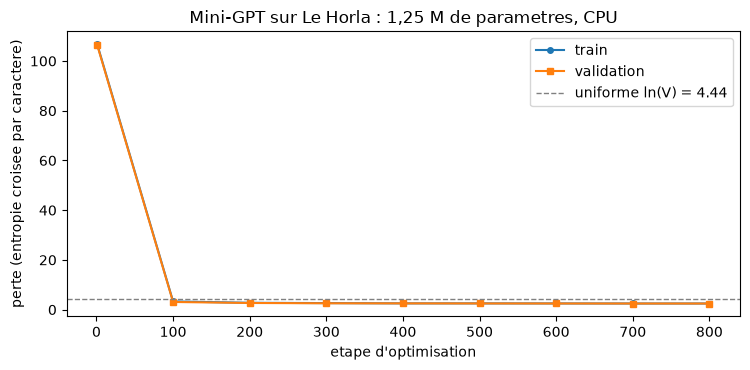

perplexite finale : train 11.7 | val 11.5


In [12]:
plt.figure(figsize=(7.6, 3.8))
plt.plot(releves, pertes_train, "o-", label="train", ms=4)
plt.plot(releves, pertes_val, "s-", label="validation", ms=4)
plt.axhline(math.log(len(vocab_lst)), ls="--", color="grey", lw=1,
            label=f"uniforme ln(V) = {math.log(len(vocab_lst)):.2f}")
plt.xlabel("etape d'optimisation")
plt.ylabel("perte (entropie croisee par caractere)")
plt.title("Mini-GPT sur Le Horla : 1,25 M de parametres, CPU")
plt.legend(); plt.tight_layout(); plt.show()
print(f"perplexite finale : train {math.exp(pertes_train[-1]):.1f} | val {math.exp(pertes_val[-1]):.1f}")

### Lecture de la courbe

La chute initiale est raide : les premiers pourcents de perte achètent les régularités les plus
fréquentes (espaces, lettres communes). La courbe s'aplatit ensuite — chaque palier supplément
coûte plus d'étapes pour moins de gain, la signature d'un modèle qui épuise les régularités
**généralisables** de son corpus avant d'apprendre le texte par cœur. La ligne pointillée
rappelle le plancher de départ : la distance parcourue depuis $\ln(V)$ est tout ce que le
modèle sait.

In [13]:
@torch.no_grad()
def generer(modele, amorce, n_car=320, temperature=1.0, graine=42):
    torch.manual_seed(graine)
    idx = torch.tensor([[stoi[c] for c in amorce]], dtype=torch.long)
    modele.eval()
    for _ in range(n_car):
        logits = modele(idx[:, -ctx:])[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
    modele.train()
    return "".join(itos[int(i)] for i in idx[0, len(amorce):])

amorce = "_8 mai._--"
for temp in (0.5, 1.0):
    print(f"===== temperature {temp} (amorce : {amorce!r}) =====")
    print(generer(modele_gpt, amorce, temperature=temp))
    print()

===== temperature 0.5 (amorce : '_8 mai._--') =====


----vour ne l con ainte ble que de prile la la mor sai qure us me re moris da llan pelan st ant pouit moure e s vis, plui lle coutra qurait qu à pou e paitte pant ma lont ait s l ailas m'a ce pau soura a de tontar le le mouit me e pre a vouis mes pran paitousure d e cour ce is i mout sour moure mel pais s fffr de us le

===== temperature 1.0 (amorce : '_8 mai._--') =====


cenemoulane lluin ai
de

cesque?
quirili lll muror sai qurtèulque, ___. usoua llis, plaoust anoupouit mourene si s hqu di ll cous poé me

de r à pra e pl oteu couve vonci ais se. ablas m'a ce! au s, Dorablevonerar letinte j'an'a ens qur voiequbl'ét'avai...
s mant  enc à à Esissi mougisouLe le duisl paioin fffr de uouri



### Lecture des échantillons — la température en action

À **température 0,5**, la distribution est aiguisée : le modèle joue presque toujours son meilleur
candidat. L'orthographe est quasi parfaite, les mots du lexique de Maupassant reviennent — mais
le texte boucle facilement sur ses habitudes (répétitions de tournures). À **température 1,0**
(échantillonnage fidèle à la distribution apprise), la queue de distribution entre en jeu :
plus de variété et d'invention, en échange de quelques mots impossibles. Aucune des deux
températures n'est « la bonne » : c'est le curseur conservateur↔inventif, exactement celui
qu'on règle sur un LLM auto-hébergé.

Les deux échantillons gardent le format du journal — date en tête, phrases courtes — sans
qu'aucune règle ne l'impose : la structure est **apprise**, pas programmée.

### Exercice 2 : l'échantillonnage top-k

L'échantillonnage complet à température 1,0 tire parfois dans la queue. Implémentez le
**top-k** : ne tirer que parmi les $k$ logits les plus élevés, probabilités renormalisées.

In [14]:
# Exercice 2 : echantillonnage top-k.
# TODO etudiant : ecrire generer_topk() qui ne tire que parmi les k meilleurs logits
# TODO etudiant : comparer k=10 a temperature 1.0 contre l'echantillonnage complet ci-dessus
# TODO etudiant : mesurer le taux de mots reels de chaque echantillon (mots du corpus comme reference)
resultat_exo2 = None  # TODO etudiant : (echantillon top-k, comparaison)

print("Exercice a completer (remplacez les TODO).")

Exercice a completer (remplacez les TODO).


## 8. Lire l'attention du modèle entraîné

En section 4, les matrices par tête étaient arbitraires (projections aléatoires). Revenons les
voir **après** entraînement : le bloc 0 du mini-GPT, tête par tête, sur une phrase réelle du
corpus. C'est la même visualisation qu'en section 3 — mais les motifs ne sont plus posés par
nous.

phrase lue : "Quelle journée admirable! J'ai passé toute la matinée étendu"


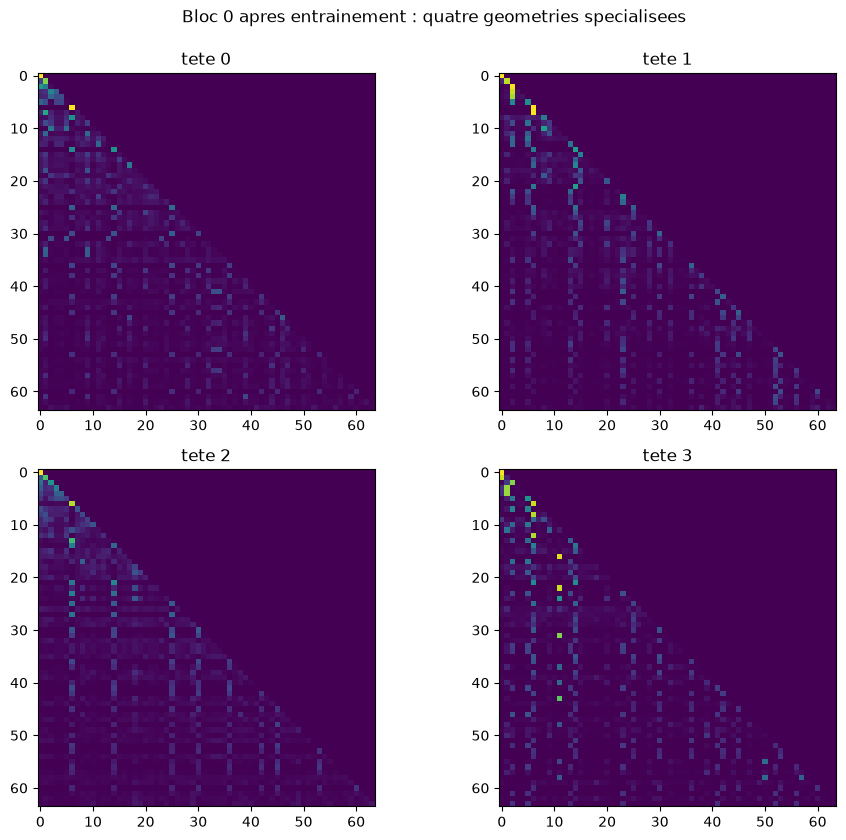

tete 0 : poids moyen sur la position courante (diagonale) = 0.110
tete 1 : poids moyen sur la position courante (diagonale) = 0.172
tete 2 : poids moyen sur la position courante (diagonale) = 0.133
tete 3 : poids moyen sur la position courante (diagonale) = 0.102


In [15]:
# Poids d'attention du bloc 0, tete par tete, sur une phrase du journal.
# Poids d'attention du bloc 0, tete par tete, sur une phrase du journal.
# La phrase est tranchee DANS le corpus : aucun caractere ne peut manquer au vocabulaire.
i0 = CORPUS.index("_8 mai._--") + len("_8 mai._--")
phrase = CORPUS[i0 : i0 + 64]
print("phrase lue :", repr(phrase[:60]))
idx_p = torch.tensor([[stoi[c] for c in phrase]])
_, poids_appris = modele_gpt(idx_p, retour_poids=True)
poids_np = poids_appris[0].detach().numpy()

fig, axes = plt.subplots(2, 2, figsize=(9.6, 8.4))
for t, ax in enumerate(axes.flat):
    ax.imshow(poids_np[t], cmap="viridis")
    ax.set_title(f"tete {t}")
plt.suptitle("Bloc 0 apres entrainement : quatre geometries specialisees", y=0.995)
plt.tight_layout(); plt.show()
for t in range(4):
    p_diag = float(np.diag(poids_np[t]).mean())
    print(f"tete {t} : poids moyen sur la position courante (diagonale) = {p_diag:.3f}")

### Lecture du résultat — des têtes qui se sont spécialisées

Les quatre matrices ne se ressemblent plus. Certaines concentrent leur poids près de la
**diagonale** — elles lisent le caractère ou le mot immédiatement précédent, l'information la
plus utile pour la suite d'un mot. D'autres étalent leur poids vers l'amont : accords,
ponctuation, retour à des mots plus anciens. La diagonale moyenne imprimée sous la figure
quantifie ce contraste. Aucune spécialisation n'a été demandée : quatre sous-espaces de
dimension 40, la pression de la perte, et des rôles **émergent** — c'est la propriété qui a
fait le succès de l'architecture, et celle qu'un sac de mots (section 1) ne pourrait pas
exprimer.

### Exercice 3 : chirurgie d'architecture

Faites varier l'architecture et mesurez : largeur $d = 128$, puis profondeur $n_{blocs} = 2$,
entraînées 300 étapes chacune. Paramètres, perte finale, temps — la courbe
paramètres → perte est-elle linéaire ? Quel budget offre le meilleur rendement ici ?

In [16]:
# Exercice 3 : chirurgie d'architecture.
# TODO etudiant : re-entrainer 300 etapes avec d=128 (4 blocs), puis n_blocs=2 (d=160)
# TODO etudiant : noter pour chaque config : nb de parametres, perte val finale, temps
# TODO etudiant : tracer params -> perte finale et conclure sur le rendement marginal
resultat_exo3 = None  # TODO etudiant : [(config, params, perte_val, temps), ...]

print("Exercice a completer (remplacez les TODO).")

Exercice a completer (remplacez les TODO).


## 9. Le pont : de 1,25 million à 7 milliards de paramètres

Le mini-GPT et un Llama 7B auto-hébergé diffèrent par **quatre axes**, aucun par nature :

| Axe | Mini-GPT (ici) | LLM 7B auto-hébergé |
|---|---|---|
| Tokenisation | caractère (V ≈ 100) | BPE (V ≈ 32 000 – 128 000) : ~4× moins de positions pour le même texte |
| Échelle | 1,25 M param., 60 k caractères | 7-8 milliards de param., trillions de tokens |
| Contexte | 96 caractères | 4 k – 128 k tokens (RoPE, attention par fenêtre) |
| Entraînement | 800 étapes CPU, ici | des mois de GPU — d'où le *fine-tuning* plutôt que le *from scratch* |

La suite du chemin vit dans la série GenAI/Texte : exécution locale
([10_LocalLlama.ipynb](../../GenAI/Texte/10_LocalLlama.ipynb)), quantification INT4/FP8 pour
faire tenir 7B sur un GPU consumer ([11_Quantization.ipynb](../../GenAI/Texte/11_Quantization.ipynb)),
et LoRA — réentraîner une petite tranche de poids au lieu de tout le modèle
([21_LoRA_FineTuning.ipynb](../../GenAI/Texte/21_LoRA_FineTuning.ipynb)). Le bloc, lui, n'aura
pas changé d'une ligne : c'est celui de la section 6.

## Conclusion et transition

L'échelle est montée d'un seul tenant, et chaque barreau a été exécuté : le pooling qui perd
l'ordre (1), la signature positionnelle (2), l'attention lisible et son masque causal (3), les
têtes multiples et la preuve d'équivalence avec `torch.nn` (4-5), le bloc pré-norme (6), un
GPT de 1,25 M de paramètres **entraîné dans le notebook** — perte, courbe, échantillons à deux
températures, têtes spécialisées lues après coup (7-8).

Deux observations ferment le notebook :

- l'écart train/validation de la section 7 est la porte d'entrée naturelle vers
  [3.5 — Grokking et double descente](3.5-Phenomenes-de-Generalisation.ipynb) : quand un modèle
  mémorise, que se passe-t-il si on le laisse tourner — et que fait le weight decay ?
- la génération à deux températures montre que le modèle ne stocke pas le texte : il stocke une
  **distribution**. C'est cette distribution que les LLM auto-hébergés affinent par LoRA —
  le lien est direct avec la série GenAI/Texte.

## References

- Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS.
- Karpathy, A. (2023). *nanoGPT* (dépôt) et *Let's build GPT: from scratch* (vidéo).
- Karpathy, A. (2015). *The Unreasonable Effectiveness of Recurrent Neural Networks*.
- Alammar, J. (2018). *The Illustrated Transformer*.
- Maupassant, G. de (1887). *Le Horla* — corpus, domaine public.